# Stock Price Prediction Pipeline1

This notebook integrates:
1. **Feature Extraction** (with toggle to skip if data already exists)
2. **Initial Visualizations** 
3. **Model Training** (Logistic Regression, Random Forest, XGBoost, and PyTorch Neural Network)

Goal: Predict whether AAPL stock price goes Up or Down on the next day (BINARY CLASSIFICATION).


In [1]:
# Import all necessary libraries
import os
import json
import pandas as pd
import numpy as np
from datetime import datetime
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

# Machine Learning
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.model_selection import RandomizedSearchCV, GridSearchCV, StratifiedKFold
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report,
    precision_recall_fscore_support,
    f1_score,
    roc_auc_score,
    roc_curve,
)
import joblib

# XGBoost
try:
    import xgboost as xgb
    XGBOOST_AVAILABLE = True
except ImportError:
    print("Warning: XGBoost not installed. Install with: pip install xgboost")
    XGBOOST_AVAILABLE = False

# PyTorch
try:
    import torch
    import torch.nn as nn
    import torch.optim as optim
    from torch.utils.data import Dataset, DataLoader
    PYTORCH_AVAILABLE = True
    PYTORCH_CUDA_AVAILABLE = torch.cuda.is_available()
    if PYTORCH_CUDA_AVAILABLE:
        CUDA_VERSION = torch.version.cuda if hasattr(torch.version, 'cuda') else "unknown"
        print(f"PyTorch CUDA available - Version: {CUDA_VERSION}")
except ImportError:
    print("Warning: PyTorch not installed. Install with: pip install torch")
    PYTORCH_AVAILABLE = False
    PYTORCH_CUDA_AVAILABLE = False

# Configuration
RAW_CSV = "test4.csv"
PROCESSED_CSV = "processedtest4.csv"
OUT_MODEL_DIR = "models"
OUT_PLOTS_DIR = "plots"
OUT_RESULTS_DIR = "results"
DEFAULT_TRAIN_FRAC = 0.8
RANDOM_SEED = 42
DELTA = 0.004

# Ensure directories exist
os.makedirs(OUT_MODEL_DIR, exist_ok=True)
os.makedirs(OUT_PLOTS_DIR, exist_ok=True)
os.makedirs(OUT_RESULTS_DIR, exist_ok=True)

print("Libraries imported successfully!")
if XGBOOST_AVAILABLE:
    print("XGBoost is available ✓")
else:
    print("XGBoost is NOT available ✗")
if PYTORCH_AVAILABLE:
    print(f"PyTorch is available ✓ (CUDA: {'Yes' if PYTORCH_CUDA_AVAILABLE else 'No'})")
else:
    print("PyTorch is NOT available ✗")


Libraries imported successfully!
XGBoost is available ✓
PyTorch is available ✓ (CUDA: No)


## Step 1: Feature Extraction (Toggle)

Set `RUN_FEATURE_EXTRACTION = True` to run feature extraction, or `False` to skip if processed data already exists.


In [2]:
# TOGGLE: Set to False to skip feature extraction if processedtest4.csv already exists
RUN_FEATURE_EXTRACTION = True

if RUN_FEATURE_EXTRACTION:
    print("Running feature extraction...")
    
    # Import feature extraction functions
    import sys
    sys.path.append('.')
    
    # We'll run the feature extraction logic inline
    # DELTA is defined in the configuration section (Cell 1)
    EXTREME_THRESHOLD = 0.25
    CLEANING_LOG = "cleaning_log.csv"
    
    def load_raw(path):
        if not os.path.exists(path):
            raise FileNotFoundError(f"Raw CSV not found: {path}. Run getData.py first.")
        df = pd.read_csv(path, parse_dates=["Date"], index_col="Date")
        try:
            df.index = pd.to_datetime(df.index, utc=True).tz_convert(None)
        except Exception:
            df.index = pd.to_datetime(df.index).tz_localize(None, ambiguous='infer', nonexistent='shift_forward')
        df = df.sort_index()
        return df
    
    def price_consistency_check(df):
        cond = (
            (df['Open'] > df['High']) |
            (df['Close'] > df['High']) |
            (df['Low'] > df['Open']) |
            (df['Low'] > df['Close'])
        )
        violations = df[cond]
        if len(violations) > 0:
            os.makedirs("data", exist_ok=True)
            violations.reset_index().to_csv("data/price_consistency_violations.csv", index=False)
            df = df.drop(index=violations.index)
            print(f"[CLEAN] Price consistency: dropped {len(violations)} rows")
        else:
            print("[CLEAN] Price consistency: no violations found.")
        return df
    
    def corporate_actions_check(df):
        if 'Adj Close' not in df.columns:
            print("[CLEAN] Warning: 'Adj Close' column not found.")
        else:
            if 'Stock Splits' in df.columns:
                splits = df[df['Stock Splits'] != 0][['Stock Splits']]
                if len(splits) > 0:
                    os.makedirs("data", exist_ok=True)
                    splits.reset_index().to_csv("data/splits_logged.csv", index=False)
                    print(f"[CLEAN] Logged {len(splits)} stock split rows")
            if 'Dividends' in df.columns:
                divs = df[df['Dividends'] != 0][['Dividends']]
                if len(divs) > 0:
                    os.makedirs("data", exist_ok=True)
                    divs.reset_index().to_csv("data/dividends_logged.csv", index=False)
                    print(f"[CLEAN] Logged {len(divs)} dividend rows")
    
    def outlier_detection(df):
        extreme = df[df['return'].abs() > EXTREME_THRESHOLD][['return']].copy()
        if len(extreme) > 0:
            os.makedirs("data", exist_ok=True)
            df.loc[extreme.index].reset_index().to_csv("data/extreme_days_fullrows.csv", index=False)
            print(f"[CLEAN] Flagged {len(extreme)} extreme-return days")
        top_pos = df['return'].nlargest(20)
        top_neg = df['return'].nsmallest(20)
        os.makedirs("data", exist_ok=True)
        pd.DataFrame({'date': top_pos.index, 'return': top_pos.values}).to_csv("data/top5_positive_returns.csv", index=False)
        pd.DataFrame({'date': top_neg.index, 'return': top_neg.values}).to_csv("data/top5_negative_returns.csv", index=False)
    
    def label_return(r, delta=DELTA):
        """
        BINARY classification: Up or Down only (no Same class)
        Returns "Up" if return > delta, "Down" otherwise
        """
        if pd.isna(r):
            return np.nan
        if r > delta:
            return "Up"
        else:
            return "Down"  # Includes neutral/small moves as "Down"
    
    def create_features(df):
        if 'Adj Close' not in df.columns and 'Close' in df.columns:
            df['Adj Close'] = df['Close']
        
        df['return'] = df['Adj Close'].pct_change()
        df['label'] = df['return'].apply(lambda x: label_return(x))
        
        outlier_detection(df)
        
        n_before = len(df)
        
        df['ret_lag1'] = df['return'].shift(1)
        df['ret_lag2'] = df['return'].shift(2)
        df['ma5'] = df['Adj Close'].rolling(window=5).mean().pct_change()
        df['ma10'] = df['Adj Close'].rolling(window=10).mean().pct_change()
        df['vol30'] = df['return'].rolling(window=30).std()
        df['vol10'] = df['return'].rolling(window=10).std()
        df['vol_ratio'] = df['vol10'] / (df['vol30'] + 1e-12)
        df['vol_lag1'] = df['vol30'].shift(1)
        df['vol_lag2'] = df['vol30'].shift(2)
        df['volume_lag1'] = df['Volume'].shift(1) if 'Volume' in df.columns else np.nan
        df['vol_change'] = df['Volume'] / (df['volume_lag1'] + 1e-12) - 1 if 'Volume' in df.columns else np.nan
        
        feature_cols = [
            'ret_lag1','ret_lag2','ma5','ma10','vol30','vol10',
            'vol_ratio','vol_lag1','vol_lag2','vol_change'
        ]
        df_model = df.dropna(subset=feature_cols + ['label']).copy()
        
        n_after = len(df_model)
        summary = {
            "timestamp": pd.Timestamp.utcnow().isoformat(),
            "n_before": int(n_before),
            "n_after": int(n_after),
            "n_dropped": int(n_before - n_after)
        }
        if os.path.exists(CLEANING_LOG):
            try:
                existing = pd.read_csv(CLEANING_LOG)
                combined = pd.concat([existing, pd.DataFrame([summary])], ignore_index=True)
                combined.to_csv(CLEANING_LOG, index=False)
            except Exception:
                pd.DataFrame([summary]).to_csv(CLEANING_LOG, index=False)
        else:
            pd.DataFrame([summary]).to_csv(CLEANING_LOG, index=False)
        print(f"[CLEAN] Feature creation complete. Rows: {n_before} -> {n_after} (dropped {n_before - n_after})")
        
        out_cols = ['Adj Close', 'return', 'label'] + [c for c in feature_cols if c in df_model.columns] + (['Volume'] if 'Volume' in df_model.columns else [])
        out_cols = [c for c in out_cols if c in df_model.columns]
        return df_model[out_cols]
    
    # Run feature extraction
    print(f"[RUN] Loading raw CSV from: {RAW_CSV}")
    df = load_raw(RAW_CSV)
    df = price_consistency_check(df)
    corporate_actions_check(df)
    processed = create_features(df)
    processed.to_csv(PROCESSED_CSV)
    print(f"[RUN] Processed dataset saved to {PROCESSED_CSV} (rows: {len(processed)})")
    print("[RUN] Feature extraction complete!")
else:
    print(f"Skipping feature extraction. Using existing {PROCESSED_CSV}")
    if not os.path.exists(PROCESSED_CSV):
        print(f"WARNING: {PROCESSED_CSV} not found! Set RUN_FEATURE_EXTRACTION = True")


Running feature extraction...
[RUN] Loading raw CSV from: test4.csv


[CLEAN] Price consistency: dropped 4 rows
[CLEAN] Warning: 'Adj Close' column not found.


[CLEAN] Flagged 2 extreme-return days
[CLEAN] Feature creation complete. Rows: 7546 -> 7514 (dropped 32)
[RUN] Processed dataset saved to processedtest4.csv (rows: 7514)
[RUN] Feature extraction complete!


## Step 2: Initial Visualizations

Create initial visualizations from the processed data.


In [3]:
# Load data for visualizations
file_path = RAW_CSV
if not os.path.exists(file_path):
    raise FileNotFoundError(f"{file_path} not found. Make sure your file is uploaded.")

# Load CSV
df_viz = pd.read_csv(file_path, parse_dates=["Date"], index_col="Date")

# Handle tz-aware datetimes safely
try:
    idx = pd.to_datetime(df_viz.index)
    if idx.tz is not None:
        idx = idx.tz_convert(None)
    df_viz.index = idx
except Exception:
    df_viz.index = pd.to_datetime(df_viz.index, utc=True).tz_convert(None)

required_cols = ['Open','High','Low','Close','Volume','Dividends','Stock Splits']
for c in required_cols:
    if c not in df_viz.columns:
        raise KeyError(f"Required column {c} not found in CSV columns: {list(df_viz.columns)}")

if 'Adj Close' not in df_viz.columns:
    df_viz['Adj Close'] = df_viz['Close']

df_viz = df_viz.sort_index()

# Calculate returns and labels
# DELTA is defined in the configuration section (Cell 1)
def label_return(r, delta=DELTA):
    """
    BINARY classification: Up or Down only (no Same class)
    Returns "Up" if return > delta, "Down" otherwise
    """
    if pd.isna(r):
        return np.nan
    if r > delta:
        return "Up"
    else:
        return "Down"  # Includes neutral/small moves as "Down"

df_viz['return'] = df_viz['Adj Close'].pct_change()
df_viz['label'] = df_viz['return'].apply(lambda x: label_return(x))
df_viz = df_viz.dropna(subset=['return'])

class_counts = df_viz['label'].value_counts()

# Calculate features for visualization
df_viz['volatility_rolling'] = df_viz['return'].rolling(window=30).std() * np.sqrt(252)

print("Data loaded for visualizations!")


Data loaded for visualizations!


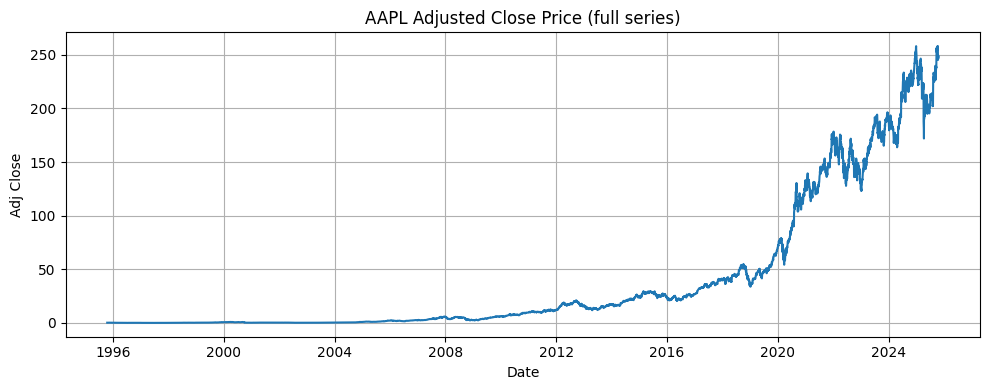

In [4]:
# Plot 1: Adjusted Close price time series (full)
plt.figure(figsize=(10,4))
plt.plot(df_viz['Adj Close'])
plt.title("AAPL Adjusted Close Price (full series)")
plt.xlabel("Date")
plt.ylabel("Adj Close")
plt.grid(True)
plt.tight_layout()
plt.show()


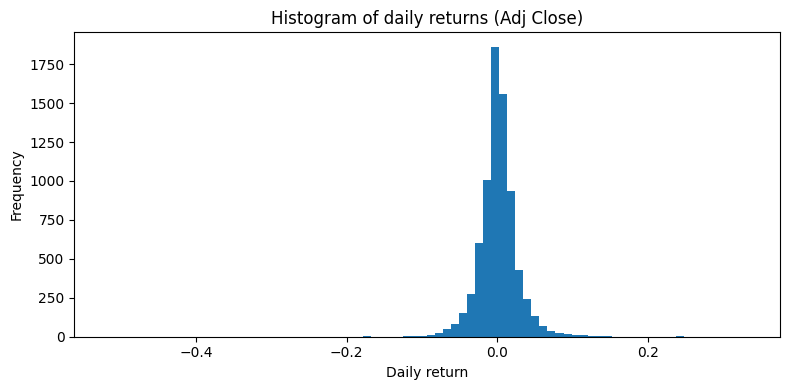

In [5]:
# Plot 2: Histogram of daily returns (zoomed)
plt.figure(figsize=(8,4))
plt.hist(df_viz['return'].dropna().values, bins=80)
plt.title("Histogram of daily returns (Adj Close)")
plt.xlabel("Daily return")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()


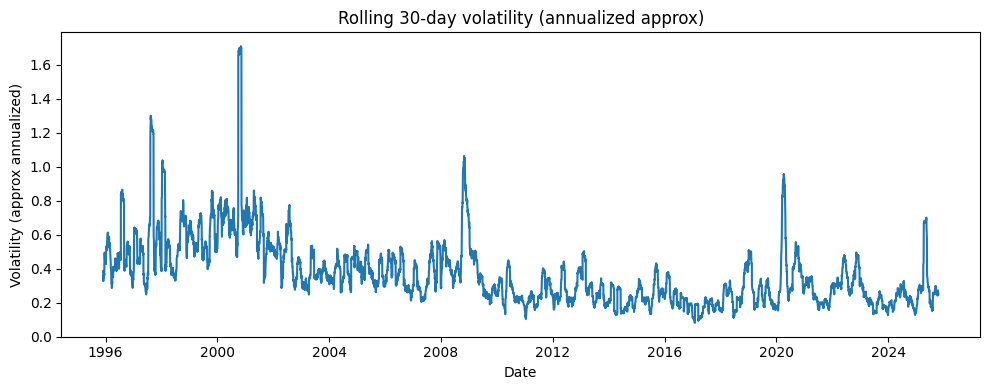

In [6]:
# Plot 3: Rolling volatility (30-day)
plt.figure(figsize=(10,4))
plt.plot(df_viz['volatility_rolling'])
plt.title("Rolling 30-day volatility (annualized approx)")
plt.xlabel("Date")
plt.ylabel("Volatility (approx annualized)")
plt.tight_layout()
plt.show()


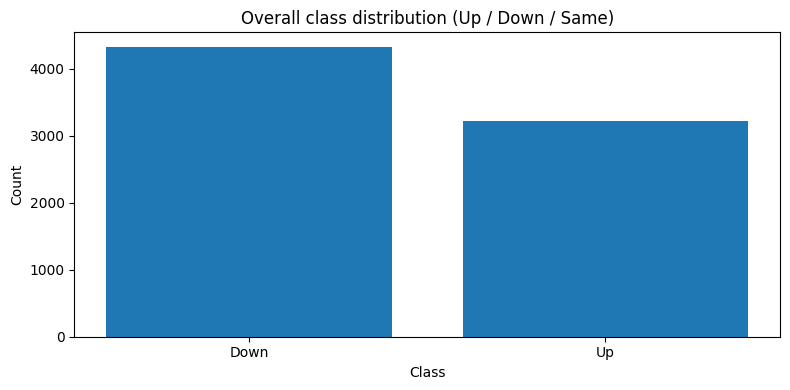

In [7]:
# Plot 4: Class distribution bar chart (overall)
plt.figure(figsize=(8,4))
plt.bar(class_counts.index.astype(str), class_counts.values)
plt.title("Overall class distribution (Up / Down / Same)")
plt.xlabel("Class")
plt.ylabel("Count")
plt.tight_layout()
plt.show()


## Delta Threshold Analysis

**Understanding the Delta Issue**: The `DELTA` parameter controls what counts as "Same" vs "Up/Down". 
- Without delta (binary classification): You'd predict Up vs Down, which could achieve ~50% accuracy by chance
- With delta: Creates 3 classes (Up/Down/Same), but the "Same" class can be problematic if delta is too small or too large

Let's analyze the impact of different delta values on class distribution.


DELTA THRESHOLD ANALYSIS

Class Distribution by Delta Threshold:
 delta   Up  Down  Same    Up_pct  Down_pct  Same_pct  min_class_pct
 0.000 3900  3574    75 51.662472 47.344019  0.993509       0.993509
 0.001 3738  3415   396 49.516492 45.237780  5.245728       5.245728
 0.002 3565  3239   745 47.224798 42.906345  9.868857       9.868857
 0.003 3393  3058  1098 44.946351 40.508677 14.544973      14.544973
 0.004 3223  2889  1437 42.694397 38.269970 19.035634      19.035634
 0.005 3062  2714  1773 40.561664 35.951782 23.486555      23.486555
 0.010 2308  1990  3251 30.573586 26.361107 43.065307      26.361107
 0.020 1201  1115  5233 15.909392 14.770168 69.320440      14.770168


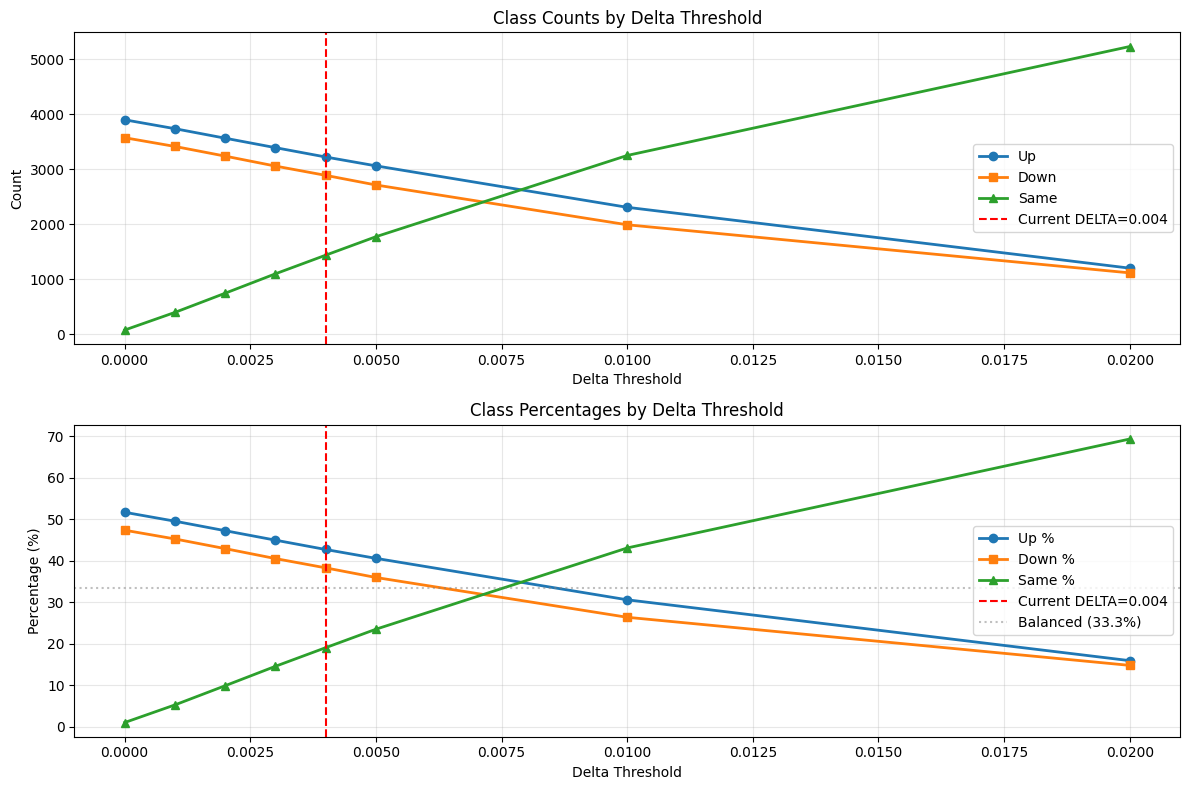


RECOMMENDATIONS:
Current DELTA = 0.004 (0.40%)
  - Same class: 19.0% of data
  - Smallest class: 19.0% of data
  ✓ Class distribution looks reasonable

Note: Without delta (delta=0), you get binary classification (Up/Down).
      This could achieve ~50% accuracy by random guessing, but:
      - Ignores days with minimal movement
      - May be easier for models to learn
      - Consider if 'Same' predictions are useful for your use case


In [8]:
# DELTA THRESHOLD ANALYSIS
# Analyze how different delta values affect class distribution

print("=" * 70)
print("DELTA THRESHOLD ANALYSIS")
print("=" * 70)

# Load raw data to analyze returns
df_delta_analysis = pd.read_csv(RAW_CSV, parse_dates=["Date"], index_col="Date")
try:
    df_delta_analysis.index = pd.to_datetime(df_delta_analysis.index, utc=True).tz_convert(None)
except Exception:
    df_delta_analysis.index = pd.to_datetime(df_delta_analysis.index).tz_localize(None, ambiguous='infer', nonexistent='shift_forward')
df_delta_analysis = df_delta_analysis.sort_index()

if 'Adj Close' not in df_delta_analysis.columns and 'Close' in df_delta_analysis.columns:
    df_delta_analysis['Adj Close'] = df_delta_analysis['Close']

df_delta_analysis['return'] = df_delta_analysis['Adj Close'].pct_change()
df_delta_analysis = df_delta_analysis.dropna(subset=['return'])

# Test different delta values
delta_values = [0.0, 0.001, 0.002, 0.003, 0.004, 0.005, 0.01, 0.02]
results = []

for delta in delta_values:
    def label_return(r, delta=delta):
        if pd.isna(r):
            return np.nan
        if r > delta:
            return "Up"
        elif r < -delta:
            return "Down"
        else:
            return "Same"
    
    labels = df_delta_analysis['return'].apply(lambda x: label_return(x))
    counts = labels.value_counts()
    total = len(labels)
    
    results.append({
        'delta': delta,
        'Up': counts.get('Up', 0),
        'Down': counts.get('Down', 0),
        'Same': counts.get('Same', 0),
        'Up_pct': counts.get('Up', 0) / total * 100,
        'Down_pct': counts.get('Down', 0) / total * 100,
        'Same_pct': counts.get('Same', 0) / total * 100,
        'min_class_pct': min(counts.get('Up', 0), counts.get('Down', 0), counts.get('Same', 0)) / total * 100
    })

results_df = pd.DataFrame(results)
print("\nClass Distribution by Delta Threshold:")
print(results_df.to_string(index=False))

# Visualize
fig, axes = plt.subplots(2, 1, figsize=(12, 8))

# Class counts
axes[0].plot(results_df['delta'], results_df['Up'], marker='o', label='Up', linewidth=2)
axes[0].plot(results_df['delta'], results_df['Down'], marker='s', label='Down', linewidth=2)
axes[0].plot(results_df['delta'], results_df['Same'], marker='^', label='Same', linewidth=2)
axes[0].axvline(x=DELTA, color='r', linestyle='--', label=f'Current DELTA={DELTA}')
axes[0].set_xlabel('Delta Threshold')
axes[0].set_ylabel('Count')
axes[0].set_title('Class Counts by Delta Threshold')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Class percentages
axes[1].plot(results_df['delta'], results_df['Up_pct'], marker='o', label='Up %', linewidth=2)
axes[1].plot(results_df['delta'], results_df['Down_pct'], marker='s', label='Down %', linewidth=2)
axes[1].plot(results_df['delta'], results_df['Same_pct'], marker='^', label='Same %', linewidth=2)
axes[1].axvline(x=DELTA, color='r', linestyle='--', label=f'Current DELTA={DELTA}')
axes[1].axhline(y=33.33, color='gray', linestyle=':', alpha=0.5, label='Balanced (33.3%)')
axes[1].set_xlabel('Delta Threshold')
axes[1].set_ylabel('Percentage (%)')
axes[1].set_title('Class Percentages by Delta Threshold')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Recommendations
print("\n" + "=" * 70)
print("RECOMMENDATIONS:")
print("=" * 70)
print(f"Current DELTA = {DELTA} ({DELTA*100:.2f}%)")
current_row = results_df[results_df['delta'] == DELTA]
if len(current_row) > 0:
    same_pct = current_row['Same_pct'].values[0]
    min_pct = current_row['min_class_pct'].values[0]
    print(f"  - Same class: {same_pct:.1f}% of data")
    print(f"  - Smallest class: {min_pct:.1f}% of data")
    
    if same_pct < 5:
        print("  ⚠️  WARNING: 'Same' class is very small (<5%). Consider:")
        print("     - Increasing DELTA to capture more 'Same' days")
        print("     - OR removing 'Same' class and doing binary classification")
    elif same_pct > 50:
        print("  ⚠️  WARNING: 'Same' class is too large (>50%). Consider:")
        print("     - Decreasing DELTA to make classification more meaningful")
    elif min_pct < 10:
        print("  ⚠️  WARNING: One class is very small (<10%). This can cause:")
        print("     - Poor model performance on minority class")
        print("     - Need for class balancing techniques")
    else:
        print("  ✓ Class distribution looks reasonable")

print("\nNote: Without delta (delta=0), you get binary classification (Up/Down).")
print("      This could achieve ~50% accuracy by random guessing, but:")
print("      - Ignores days with minimal movement")
print("      - May be easier for models to learn")
print("      - Consider if 'Same' predictions are useful for your use case")


### Fix: Corrected Feature Extraction (No Data Leakage)

This cell creates a corrected version that:
1. Shifts labels forward to predict tomorrow's return
2. Ensures features only use past information
3. Creates a new processed file with correct alignment


In [9]:
# ENHANCED FEATURE EXTRACTION - WITH TECHNICAL INDICATORS
# Set to True to regenerate data with enhanced features
REGENERATE_FIXED_DATA = True  # Set to True to create enhanced dataset

# Try to import pandas-ta for technical indicators
try:
    import pandas_ta as ta
    PANDAS_TA_AVAILABLE = True
except ImportError:
    print("Warning: pandas-ta not installed. Install with: pip install pandas-ta")
    print("Will use manual implementations for technical indicators.")
    PANDAS_TA_AVAILABLE = False

if REGENERATE_FIXED_DATA:
    print("Creating ENHANCED dataset with technical indicators and advanced features...")
    
    # Load raw data
    df_fixed = pd.read_csv(RAW_CSV, parse_dates=["Date"], index_col="Date")
    try:
        df_fixed.index = pd.to_datetime(df_fixed.index, utc=True).tz_convert(None)
    except Exception:
        df_fixed.index = pd.to_datetime(df_fixed.index).tz_localize(None, ambiguous='infer', nonexistent='shift_forward')
    df_fixed = df_fixed.sort_index()
    
    if 'Adj Close' not in df_fixed.columns and 'Close' in df_fixed.columns:
        df_fixed['Adj Close'] = df_fixed['Close']
    
    # Calculate returns
    df_fixed['return'] = df_fixed['Adj Close'].pct_change()
    
    # FIX: Shift label forward to predict TOMORROW's return
    # BINARY CLASSIFICATION: Up or Down only (no Same class)
    def label_return_fixed(r, delta=DELTA):
        """
        BINARY classification: Up or Down only (no Same class)
        Returns "Up" if return > delta, "Down" otherwise
        """
        if pd.isna(r):
            return np.nan
        if r > delta:
            return "Up"
        else:
            return "Down"  # Includes neutral/small moves as "Down"
    
    df_fixed['return_next'] = df_fixed['return'].shift(-1)  # Tomorrow's return
    df_fixed['label'] = df_fixed['return_next'].apply(lambda x: label_return_fixed(x))
    
    print("Creating enhanced features...")
    
    # ========== 1. PRICE MOMENTUM & RETURNS ==========
    # Previous day returns
    df_fixed['ret_lag1'] = df_fixed['return'].shift(1)
    df_fixed['ret_lag2'] = df_fixed['return'].shift(2)
    df_fixed['ret_lag3'] = df_fixed['return'].shift(3)
    df_fixed['ret_lag5'] = df_fixed['return'].shift(5)
    
    # Rolling volatility (standard deviation)
    df_fixed['vol_5'] = df_fixed['return'].rolling(window=5).std()
    df_fixed['vol_10'] = df_fixed['return'].rolling(window=10).std()
    df_fixed['vol_20'] = df_fixed['return'].rolling(window=20).std()
    df_fixed['vol_30'] = df_fixed['return'].rolling(window=30).std()
    df_fixed['vol_ratio_10_30'] = df_fixed['vol_10'] / (df_fixed['vol_30'] + 1e-12)
    df_fixed['vol_ratio_5_20'] = df_fixed['vol_5'] / (df_fixed['vol_20'] + 1e-12)
    
    # ========== 2. MOVING AVERAGES & CROSSOVERS ==========
    # Simple Moving Averages
    df_fixed['sma_5'] = df_fixed['Adj Close'].rolling(window=5).mean()
    df_fixed['sma_10'] = df_fixed['Adj Close'].rolling(window=10).mean()
    df_fixed['sma_20'] = df_fixed['Adj Close'].rolling(window=20).mean()
    df_fixed['sma_50'] = df_fixed['Adj Close'].rolling(window=50).mean()
    
    # Exponential Moving Averages
    df_fixed['ema_5'] = df_fixed['Adj Close'].ewm(span=5, adjust=False).mean()
    df_fixed['ema_10'] = df_fixed['Adj Close'].ewm(span=10, adjust=False).mean()
    df_fixed['ema_20'] = df_fixed['Adj Close'].ewm(span=20, adjust=False).mean()
    
    # Price relative to moving averages
    df_fixed['price_sma5_ratio'] = df_fixed['Adj Close'] / (df_fixed['sma_5'] + 1e-12) - 1
    df_fixed['price_sma20_ratio'] = df_fixed['Adj Close'] / (df_fixed['sma_20'] + 1e-12) - 1
    df_fixed['price_ema10_ratio'] = df_fixed['Adj Close'] / (df_fixed['ema_10'] + 1e-12) - 1
    
    # Moving average crossovers
    df_fixed['sma5_sma20_cross'] = (df_fixed['sma_5'] - df_fixed['sma_20']) / (df_fixed['sma_20'] + 1e-12)
    df_fixed['ema5_ema20_cross'] = (df_fixed['ema_5'] - df_fixed['ema_20']) / (df_fixed['ema_20'] + 1e-12)
    df_fixed['sma10_sma50_cross'] = (df_fixed['sma_10'] - df_fixed['sma_50']) / (df_fixed['sma_50'] + 1e-12)
    
    # MA momentum (rate of change)
    df_fixed['sma5_momentum'] = df_fixed['sma_5'].pct_change()
    df_fixed['sma20_momentum'] = df_fixed['sma_20'].pct_change()
    
    # ========== 3. TECHNICAL INDICATORS ==========
    # RSI (Relative Strength Index) - manual implementation
    def calculate_rsi(prices, period=14):
        delta = prices.diff()
        gain = (delta.where(delta > 0, 0)).rolling(window=period).mean()
        loss = (-delta.where(delta < 0, 0)).rolling(window=period).mean()
        rs = gain / (loss + 1e-12)
        rsi = 100 - (100 / (1 + rs))
        return rsi
    
    df_fixed['rsi_14'] = calculate_rsi(df_fixed['Adj Close'], 14)
    df_fixed['rsi_7'] = calculate_rsi(df_fixed['Adj Close'], 7)
    
    # MACD (Moving Average Convergence Divergence)
    ema_12 = df_fixed['Adj Close'].ewm(span=12, adjust=False).mean()
    ema_26 = df_fixed['Adj Close'].ewm(span=26, adjust=False).mean()
    df_fixed['macd'] = ema_12 - ema_26
    df_fixed['macd_signal'] = df_fixed['macd'].ewm(span=9, adjust=False).mean()
    df_fixed['macd_histogram'] = df_fixed['macd'] - df_fixed['macd_signal']
    
    # Stochastic Oscillator
    low_14 = df_fixed['Low'].rolling(window=14).min()
    high_14 = df_fixed['High'].rolling(window=14).max()
    df_fixed['stoch_k'] = 100 * ((df_fixed['Adj Close'] - low_14) / (high_14 - low_14 + 1e-12))
    df_fixed['stoch_d'] = df_fixed['stoch_k'].rolling(window=3).mean()
    
    # Bollinger Bands
    bb_period = 20
    bb_std = 2
    df_fixed['bb_middle'] = df_fixed['Adj Close'].rolling(window=bb_period).mean()
    bb_std_val = df_fixed['Adj Close'].rolling(window=bb_period).std()
    df_fixed['bb_upper'] = df_fixed['bb_middle'] + (bb_std * bb_std_val)
    df_fixed['bb_lower'] = df_fixed['bb_middle'] - (bb_std * bb_std_val)
    df_fixed['bb_width'] = (df_fixed['bb_upper'] - df_fixed['bb_lower']) / (df_fixed['bb_middle'] + 1e-12)
    df_fixed['bb_position'] = (df_fixed['Adj Close'] - df_fixed['bb_lower']) / (df_fixed['bb_upper'] - df_fixed['bb_lower'] + 1e-12)
    
    # Support/Resistance (simplified: recent highs/lows)
    df_fixed['high_20'] = df_fixed['High'].rolling(window=20).max()
    df_fixed['low_20'] = df_fixed['Low'].rolling(window=20).min()
    df_fixed['high_50'] = df_fixed['High'].rolling(window=50).max()
    df_fixed['low_50'] = df_fixed['Low'].rolling(window=50).min()
    df_fixed['price_high20_ratio'] = df_fixed['Adj Close'] / (df_fixed['high_20'] + 1e-12) - 1
    df_fixed['price_low20_ratio'] = df_fixed['Adj Close'] / (df_fixed['low_20'] + 1e-12) - 1
    
    # ========== 4. VOLUME-BASED FEATURES ==========
    if 'Volume' in df_fixed.columns:
        # Volume changes
        df_fixed['volume_lag1'] = df_fixed['Volume'].shift(1)
        df_fixed['volume_lag5'] = df_fixed['Volume'].shift(5)
        df_fixed['vol_change'] = df_fixed['Volume'] / (df_fixed['volume_lag1'] + 1e-12) - 1
        df_fixed['vol_change_5'] = df_fixed['Volume'] / (df_fixed['volume_lag5'] + 1e-12) - 1
        
        # Volume moving averages
        df_fixed['vol_ma5'] = df_fixed['Volume'].rolling(window=5).mean()
        df_fixed['vol_ma20'] = df_fixed['Volume'].rolling(window=20).mean()
        df_fixed['vol_ratio_ma'] = df_fixed['Volume'] / (df_fixed['vol_ma20'] + 1e-12)
        
        # VWAP (Volume Weighted Average Price) - daily approximation
        typical_price = (df_fixed['High'] + df_fixed['Low'] + df_fixed['Adj Close']) / 3
        df_fixed['vwap'] = (typical_price * df_fixed['Volume']).rolling(window=20).sum() / (df_fixed['Volume'].rolling(window=20).sum() + 1e-12)
        df_fixed['price_vwap_ratio'] = df_fixed['Adj Close'] / (df_fixed['vwap'] + 1e-12) - 1
        
        # On-Balance Volume (OBV)
        obv = np.zeros(len(df_fixed))
        obv[0] = df_fixed['Volume'].iloc[0]
        for i in range(1, len(df_fixed)):
            if df_fixed['Adj Close'].iloc[i] > df_fixed['Adj Close'].iloc[i-1]:
                obv[i] = obv[i-1] + df_fixed['Volume'].iloc[i]
            elif df_fixed['Adj Close'].iloc[i] < df_fixed['Adj Close'].iloc[i-1]:
                obv[i] = obv[i-1] - df_fixed['Volume'].iloc[i]
            else:
                obv[i] = obv[i-1]
        df_fixed['obv'] = obv
        df_fixed['obv_change'] = df_fixed['obv'].pct_change()
        
        # Money Flow Index (MFI)
        typical_price_mfi = (df_fixed['High'] + df_fixed['Low'] + df_fixed['Adj Close']) / 3
        raw_money_flow = typical_price_mfi * df_fixed['Volume']
        positive_flow = raw_money_flow.where(typical_price_mfi > typical_price_mfi.shift(1), 0).rolling(window=14).sum()
        negative_flow = raw_money_flow.where(typical_price_mfi < typical_price_mfi.shift(1), 0).rolling(window=14).sum()
        money_ratio = positive_flow / (negative_flow + 1e-12)
        df_fixed['mfi'] = 100 - (100 / (1 + money_ratio))
    else:
        print("Warning: Volume column not found. Skipping volume-based features.")
    
    # ========== 5. INTRADAY RELATIONSHIPS ==========
    df_fixed['high_low_ratio'] = (df_fixed['High'] - df_fixed['Low']) / (df_fixed['Adj Close'] + 1e-12)
    df_fixed['close_open_ratio'] = (df_fixed['Adj Close'] - df_fixed['Open']) / (df_fixed['Open'] + 1e-12)
    df_fixed['high_close_ratio'] = (df_fixed['High'] - df_fixed['Adj Close']) / (df_fixed['Adj Close'] + 1e-12)
    df_fixed['close_low_ratio'] = (df_fixed['Adj Close'] - df_fixed['Low']) / (df_fixed['Low'] + 1e-12)
    
    # Gap analysis
    df_fixed['prev_close'] = df_fixed['Adj Close'].shift(1)
    df_fixed['gap'] = (df_fixed['Open'] - df_fixed['prev_close']) / (df_fixed['prev_close'] + 1e-12)
    df_fixed['gap_filled'] = ((df_fixed['gap'] > 0) & (df_fixed['Low'] <= df_fixed['prev_close'])).astype(int) | \
                             ((df_fixed['gap'] < 0) & (df_fixed['High'] >= df_fixed['prev_close'])).astype(int)
    
    # ========== 6. TIME FEATURES ==========
    df_fixed['day_of_week'] = df_fixed.index.dayofweek  # 0=Monday, 6=Sunday
    df_fixed['day_of_month'] = df_fixed.index.day
    df_fixed['month'] = df_fixed.index.month
    df_fixed['quarter'] = df_fixed.index.quarter
    df_fixed['is_month_end'] = (df_fixed.index.is_month_end).astype(int)
    df_fixed['is_month_start'] = (df_fixed.index.is_month_start).astype(int)
    df_fixed['is_quarter_end'] = (df_fixed.index.is_quarter_end).astype(int)
    
    # Cyclical encoding for time features (better for ML models)
    df_fixed['day_of_week_sin'] = np.sin(2 * np.pi * df_fixed['day_of_week'] / 7)
    df_fixed['day_of_week_cos'] = np.cos(2 * np.pi * df_fixed['day_of_week'] / 7)
    df_fixed['month_sin'] = np.sin(2 * np.pi * df_fixed['month'] / 12)
    df_fixed['month_cos'] = np.cos(2 * np.pi * df_fixed['month'] / 12)
    
    # ========== 7. ADDITIONAL MOMENTUM FEATURES ==========
    # Rate of change
    df_fixed['roc_5'] = df_fixed['Adj Close'].pct_change(5)
    df_fixed['roc_10'] = df_fixed['Adj Close'].pct_change(10)
    df_fixed['roc_20'] = df_fixed['Adj Close'].pct_change(20)
    
    # Price acceleration (second derivative)
    df_fixed['return_change'] = df_fixed['return'].diff()
    
    # ========== COMPILE FEATURE LIST ==========
    feature_cols = [
        # Returns & Volatility
        'ret_lag1', 'ret_lag2', 'ret_lag3', 'ret_lag5',
        'vol_5', 'vol_10', 'vol_20', 'vol_30', 'vol_ratio_10_30', 'vol_ratio_5_20',
        # Moving Averages
        'price_sma5_ratio', 'price_sma20_ratio', 'price_ema10_ratio',
        'sma5_sma20_cross', 'ema5_ema20_cross', 'sma10_sma50_cross',
        'sma5_momentum', 'sma20_momentum',
        # Technical Indicators
        'rsi_14', 'rsi_7', 'macd', 'macd_signal', 'macd_histogram',
        'stoch_k', 'stoch_d',
        'bb_width', 'bb_position',
        'price_high20_ratio', 'price_low20_ratio',
        # Volume (if available)
        'vol_change', 'vol_change_5', 'vol_ratio_ma', 'price_vwap_ratio',
        'obv_change', 'mfi',
        # Intraday
        'high_low_ratio', 'close_open_ratio', 'high_close_ratio', 'close_low_ratio',
        'gap', 'gap_filled',
        # Time features
        'day_of_week_sin', 'day_of_week_cos', 'month_sin', 'month_cos',
        'is_month_end', 'is_month_start', 'is_quarter_end',
        # Momentum
        'roc_5', 'roc_10', 'roc_20', 'return_change'
    ]
    
    # Filter to only include columns that exist
    feature_cols = [c for c in feature_cols if c in df_fixed.columns]
    
    # Drop rows where label is NaN (last row will have NaN label since we shifted forward)
    df_fixed = df_fixed.dropna(subset=feature_cols + ['label']).copy()
    
    # Save enhanced dataset
    FIXED_PROCESSED_CSV = "processedtest4_enhanced.csv"
    out_cols = ['Adj Close', 'return', 'return_next', 'label'] + feature_cols + (['Volume'] if 'Volume' in df_fixed.columns else [])
    out_cols = [c for c in out_cols if c in df_fixed.columns]
    df_fixed[out_cols].to_csv(FIXED_PROCESSED_CSV)
    
    print(f"\n✓ Enhanced dataset saved to {FIXED_PROCESSED_CSV}")
    print(f"  Rows: {len(df_fixed)}")
    print(f"  Features: {len(feature_cols)}")
    print(f"  Label now represents TOMORROW's return classification")
    
    # Show class distribution
    print(f"\nClass distribution:")
    print(df_fixed['label'].value_counts())
    print(f"\nClass percentages:")
    print(df_fixed['label'].value_counts(normalize=True) * 100)
    
    # Show sample features
    print("\nSample of enhanced features (first 3 rows):")
    sample_cols = ['Adj Close', 'return', 'return_next', 'label', 'rsi_14', 'macd', 'vol_30', 'bb_position']
    sample_cols = [c for c in sample_cols if c in df_fixed.columns]
    print(df_fixed[sample_cols].head(3))
    
else:
    print("REGENERATE_FIXED_DATA = False. Set to True to create enhanced dataset.")


Will use manual implementations for technical indicators.
Creating ENHANCED dataset with technical indicators and advanced features...


Creating enhanced features...



✓ Enhanced dataset saved to processedtest4_enhanced.csv
  Rows: 7500
  Features: 52
  Label now represents TOMORROW's return classification

Class distribution:
label
Down    4296
Up      3204
Name: count, dtype: int64

Class percentages:
label
Down    57.28
Up      42.72
Name: proportion, dtype: float64

Sample of enhanced features (first 3 rows):
                     Adj Close    return  return_next label     rsi_14  \
Date                                                                     
1995-12-27 05:00:00   0.242976  0.009750    -0.011586  Down  19.278553   
1995-12-28 05:00:00   0.240161 -0.011586    -0.003906  Down  18.936125   
1995-12-29 05:00:00   0.239223 -0.003906     0.007843    Up  12.026564   

                         macd    vol_30  bb_position  
Date                                                  
1995-12-27 05:00:00 -0.012747  0.027817     0.180374  
1995-12-28 05:00:00 -0.013097  0.027497     0.185574  
1995-12-29 05:00:00 -0.013296  0.027497     0.208102  


In [10]:
#

In [11]:
# Integrate Sentiment Data with Stock Features
print("=" * 80)
print("SENTIMENT INTEGRATION")
print("=" * 80)

# Load the enhanced stock data (with correct label alignment)
ENHANCED_CSV = "processedtest4_enhanced.csv"
if not os.path.exists(ENHANCED_CSV):
    raise FileNotFoundError(f"Enhanced CSV not found: {ENHANCED_CSV}. Run feature extraction first.")

print(f"\n1. Loading enhanced stock data: {ENHANCED_CSV}")
df_stock = pd.read_csv(ENHANCED_CSV, parse_dates=["Date"], index_col="Date")
df_stock = df_stock.sort_index()

# Convert index to date for merging
df_stock['date'] = df_stock.index.date

print(f"   Stock data: {len(df_stock):,} rows")
print(f"   Date range: {df_stock.index.min().date()} to {df_stock.index.max().date()}")

# Load sentiment data
SENTIMENT_CSV = "apple_daily_sentiment.csv"
if not os.path.exists(SENTIMENT_CSV):
    raise FileNotFoundError(f"Sentiment CSV not found: {SENTIMENT_CSV}")

print(f"\n2. Loading sentiment data: {SENTIMENT_CSV}")
df_sentiment = pd.read_csv(SENTIMENT_CSV, parse_dates=["Date"])
df_sentiment['Date'] = pd.to_datetime(df_sentiment['Date']).dt.date
df_sentiment = df_sentiment.sort_values('Date')

print(f"   Sentiment data: {len(df_sentiment):,} rows")
print(f"   Date range: {df_sentiment['Date'].min()} to {df_sentiment['Date'].max()}")

# Merge sentiment with stock data
print(f"\n3. Merging sentiment with stock data...")
df_merged = df_stock.merge(df_sentiment, left_on='date', right_on='Date', how='left')
df_merged.index = df_stock.index  # Restore original index
df_merged = df_merged.sort_index()

# Remove temporary date columns
df_merged = df_merged.drop(columns=['date', 'Date'], errors='ignore')

# Calculate overlap statistics
has_sentiment = df_merged['VADER_Compound_Mean'].notna()
overlap_count = has_sentiment.sum()
overlap_pct = (overlap_count / len(df_merged)) * 100

print(f"   Total trading days: {len(df_merged):,}")
print(f"   Days with sentiment: {overlap_count:,} ({overlap_pct:.1f}%)")
print(f"   Days without sentiment: {(~has_sentiment).sum():,}")

if overlap_count > 0:
    overlap_dates = df_merged[has_sentiment].index
    print(f"   Sentiment coverage: {overlap_dates.min().date()} to {overlap_dates.max().date()}")

# Load Naive Bayes sentiment data (if available)
# Check for both possible filenames (script outputs to nb2.csv, but check both)
NB_SENTIMENT_CSV = None
for filename in ["apple_daily_sentiment_nb2.csv", "apple_daily_sentiment_nb.csv"]:
    if os.path.exists(filename):
        NB_SENTIMENT_CSV = filename
        break

if NB_SENTIMENT_CSV:
    print(f"\n2.5. Loading Naive Bayes sentiment data: {NB_SENTIMENT_CSV}")
    df_nb_sentiment = pd.read_csv(NB_SENTIMENT_CSV, parse_dates=["Date"])
    df_nb_sentiment['Date'] = pd.to_datetime(df_nb_sentiment['Date']).dt.date
    df_nb_sentiment = df_nb_sentiment.sort_values('Date')
    
    print(f"   NB Sentiment data: {len(df_nb_sentiment):,} rows")
    print(f"   Date range: {df_nb_sentiment['Date'].min()} to {df_nb_sentiment['Date'].max()}")
    
    # Merge NB sentiment with already-merged dataframe
    df_merged['date'] = df_merged.index.date
    df_merged = df_merged.merge(df_nb_sentiment, left_on='date', right_on='Date', how='left', suffixes=('', '_nb'))
    df_merged.index = df_stock.index  # Restore original index
    df_merged = df_merged.sort_index()
    df_merged = df_merged.drop(columns=['date', 'Date'], errors='ignore')
    
    nb_overlap = df_merged['NB_Positive_Ratio'].notna().sum()
    print(f"   Days with NB sentiment: {nb_overlap:,} ({(nb_overlap/len(df_merged)*100):.1f}%)")
else:
    print(f"\n2.5. Naive Bayes sentiment CSV not found: {NB_SENTIMENT_CSV}")
    print(f"   Skipping NB sentiment integration. Run analyze_sentiment_nb_tfidf.py first.")

# Create sentiment features with rolling averages
print(f"\n4. Creating sentiment features...")

# Use previous day's sentiment (shift by 1) to predict tomorrow's return
# This ensures we're using sentiment that was available BEFORE the prediction target
sentiment_cols = [
    'VADER_Compound_Mean',
    'VADER_Positive_Mean', 
    'VADER_Negative_Mean',
    'WordBank_Net_Sentiment',
    'WordBank_Positive_Sum',
    'WordBank_Negative_Sum'
]

# Add Naive Bayes probability-based features (if available)
if NB_SENTIMENT_CSV and 'NB_positive_Mean_Proba' in df_merged.columns:
    nb_sentiment_cols = [
        'NB_positive_Mean_Proba',      # Probability of positive sentiment
        'NB_negative_Mean_Proba',    # Probability of negative sentiment
        'NB_Positive_Ratio',           # Ratio of positive articles
        'NB_Net_Sentiment_Ratio'       # Net sentiment ratio
    ]
    sentiment_cols.extend(nb_sentiment_cols)
    print(f"   Added {len(nb_sentiment_cols)} Naive Bayes sentiment features")

# Shift sentiment by 1 day (use yesterday's sentiment to predict tomorrow)
for col in sentiment_cols:
    if col in df_merged.columns:
        # Create lagged version (previous day's sentiment)
        df_merged[f'{col}_lag1'] = df_merged[col].shift(1)
        
        # Create rolling averages (3-day and 7-day) for smoothed sentiment
        df_merged[f'{col}_ma3'] = df_merged[col].rolling(window=3, min_periods=1).mean()
        df_merged[f'{col}_ma7'] = df_merged[col].rolling(window=7, min_periods=1).mean()
        
        # Shift rolling averages by 1 day as well
        df_merged[f'{col}_ma3_lag1'] = df_merged[f'{col}_ma3'].shift(1)
        df_merged[f'{col}_ma7_lag1'] = df_merged[f'{col}_ma7'].shift(1)

# IMPROVED: Handle missing sentiment with indicator feature instead of filling with 0s
# This allows the model to learn that missing sentiment is different from neutral sentiment
print(f"\n4.5. Handling missing sentiment data...")

# Create indicator for missing sentiment (1 = missing, 0 = present)
df_merged['sentiment_missing'] = df_merged['VADER_Compound_Mean'].isna().astype(int)
print(f"   Days with missing sentiment: {df_merged['sentiment_missing'].sum():,} ({df_merged['sentiment_missing'].mean()*100:.1f}%)")

# For sentiment features: fill with 0 BUT keep the indicator
# The model can learn: missing_sentiment=1 means "no news available" vs sentiment=0 means "neutral news"
for col in df_merged.columns:
    if 'VADER' in col or 'WordBank' in col or 'NB_' in col:
        df_merged[col] = df_merged[col].fillna(0)

# Create summary statistics
sentiment_feature_cols = [col for col in df_merged.columns if 'VADER' in col or 'WordBank' in col or 'NB_' in col]
print(f"   Created {len(sentiment_feature_cols)} sentiment features (VADER + WordBank + Naive Bayes)")

# Show sample of merged data
print(f"\n5. Sample of merged data (first 5 rows with sentiment):")
sample_cols = ['Adj Close', 'return', 'return_next', 'label', 
               'VADER_Compound_Mean_lag1', 'WordBank_Net_Sentiment_lag1']
if 'NB_positive_Mean_Proba_lag1' in df_merged.columns:
    sample_cols.append('NB_positive_Mean_Proba_lag1')
sample_cols = [c for c in sample_cols if c in df_merged.columns]
print(df_merged[has_sentiment][sample_cols].head())

# Save merged dataset
OUTPUT_CSV = "processedtest4_enhanced_with_sentiment.csv"
df_merged.to_csv(OUTPUT_CSV, index=True)
print(f"\n✓ Merged dataset saved to: {OUTPUT_CSV}")
print(f"  Total rows: {len(df_merged):,}")
print(f"  Total features: {len(df_merged.columns):,}")

# Update the dataframe variable for use in model training
df = df_merged.copy()
print(f"\n[OK] Sentiment integration complete! DataFrame 'df' is ready for model training.")


SENTIMENT INTEGRATION

1. Loading enhanced stock data: processedtest4_enhanced.csv
   Stock data: 7,500 rows
   Date range: 1995-12-27 to 2025-10-15

2. Loading sentiment data: apple_daily_sentiment.csv
   Sentiment data: 6,015 rows
   Date range: 1999-09-01 to 2024-01-08

3. Merging sentiment with stock data...
   Total trading days: 7,500
   Days with sentiment: 4,499 (60.0%)
   Days without sentiment: 3,001
   Sentiment coverage: 1999-09-01 to 2024-01-08

2.5. Loading Naive Bayes sentiment data: apple_daily_sentiment_nb2.csv
   NB Sentiment data: 6,015 rows
   Date range: 1999-09-01 to 2024-01-08
   Days with NB sentiment: 4,499 (60.0%)

4. Creating sentiment features...
   Added 4 Naive Bayes sentiment features



4.5. Handling missing sentiment data...
   Days with missing sentiment: 3,001 (40.0%)
   Created 67 sentiment features (VADER + WordBank + Naive Bayes)

5. Sample of merged data (first 5 rows with sentiment):
                     Adj Close    return  return_next label  \
Date                                                          
1999-09-01 04:00:00   0.515032  0.051724     0.028233    Up   
1999-09-28 04:00:00   0.447487 -0.027523    -0.009433  Down   
1999-10-06 04:00:00   0.504244 -0.011041    -0.012092  Down   
1999-11-02 05:00:00   0.602279  0.033817     0.015577    Up   
1999-11-09 05:00:00   0.672638 -0.070039     0.020223    Up   

                     VADER_Compound_Mean_lag1  WordBank_Net_Sentiment_lag1  \
Date                                                                         
1999-09-01 04:00:00                       0.0                          0.0   
1999-09-28 04:00:00                       0.0                          0.0   
1999-10-06 04:00:00                 


✓ Merged dataset saved to: processedtest4_enhanced_with_sentiment.csv
  Total rows: 7,500
  Total features: 128

[OK] Sentiment integration complete! DataFrame 'df' is ready for model training.


## Step 3: Model Training

Train models to predict stock price direction. Supports:
- Logistic Regression
- Random Forest
- XGBoost
- PyTorch Neural Network


In [12]:
# ============================================================================
# LABEL ALIGNMENT & DATA LEAKAGE CHECK
# ============================================================================
# Verify that labels are correctly aligned (features[t] predict label[t] which is tomorrow's return)

print("=" * 80)
print("LABEL ALIGNMENT & DATA LEAKAGE VERIFICATION")
print("=" * 80)

# Load the data to check alignment
if 'df' not in globals():
    if os.path.exists("processedtest4_enhanced_with_sentiment.csv"):
        df_check = pd.read_csv("processedtest4_enhanced_with_sentiment.csv", parse_dates=["Date"], index_col="Date")
    elif os.path.exists("processedtest4_enhanced.csv"):
        df_check = pd.read_csv("processedtest4_enhanced.csv", parse_dates=["Date"], index_col="Date")
    else:
        print("ERROR: No processed CSV found!")
        df_check = None
else:
    df_check = df.copy()

if df_check is not None:
    df_check = df_check.sort_index()
    
    print("\n1. LABEL ALIGNMENT CHECK")
    print("-" * 80)
    
    # Check if return_next exists
    if 'return_next' in df_check.columns:
        print("✓ 'return_next' column found")
        
        # Sample a few rows to verify alignment
        sample_cols = ['return', 'return_next', 'label']
        if all(col in df_check.columns for col in sample_cols):
            print("\nSample data (first 5 rows):")
            print(df_check[sample_cols].head())
            
            # Verify: label should be based on return_next, not return
            print("\n2. VERIFICATION:")
            print("-" * 80)
            
            # Check a specific row
            test_idx = 0
            if len(df_check) > test_idx + 1:
                row_t = df_check.iloc[test_idx]
                row_t1 = df_check.iloc[test_idx + 1]
                
                print(f"Row {test_idx} (Day t):")
                print(f"  return[t] = {row_t['return']:.6f} (today's return)")
                print(f"  return_next[t] = {row_t['return_next']:.6f} (tomorrow's return)")
                print(f"  label[t] = {row_t['label']} (should be based on return_next)")
                
                print(f"\nRow {test_idx+1} (Day t+1):")
                print(f"  return[t+1] = {row_t1['return']:.6f} (actual next day's return)")
                
                # Verify alignment
                if abs(row_t['return_next'] - row_t1['return']) < 1e-6:
                    print(f"\n✓ CORRECT: return_next[t] matches return[t+1]")
                    print(f"✓ Label alignment is correct: features[t] predict label[t] = tomorrow's return")
                else:
                    print(f"\n❌ ERROR: return_next[t] does NOT match return[t+1]!")
                    print(f"   Difference: {abs(row_t['return_next'] - row_t1['return']):.6f}")
            else:
                print("Not enough rows to verify")
    else:
        print("❌ WARNING: 'return_next' column NOT found!")
        print("   Labels may be misaligned - they should be based on tomorrow's return")
    
    print("\n3. FEATURE LEAKAGE CHECK")
    print("-" * 80)
    
    # Check for potential leakage in feature names
    feature_cols_check = [c for c in df_check.columns if c not in ['Date', 'Adj Close', 'return', 'return_next', 'label']]
    
    # Look for features that might use future information
    suspicious_features = []
    for feat in feature_cols_check:
        # Features that might leak future info
        if any(keyword in feat.lower() for keyword in ['next', 'future', 'forward', 'lead']):
            suspicious_features.append(feat)
        # Features that use current day's return (might be OK if predicting at end of day)
        if feat == 'return' or 'return' in feat.lower():
            if 'lag' not in feat.lower() and feat != 'return':
                suspicious_features.append(feat)
    
    if suspicious_features:
        print(f"⚠️  Found {len(suspicious_features)} potentially suspicious features:")
        for feat in suspicious_features[:10]:  # Show first 10
            print(f"   - {feat}")
        if len(suspicious_features) > 10:
            print(f"   ... and {len(suspicious_features) - 10} more")
    else:
        print("✓ No obvious feature leakage detected in feature names")
    
    print("\n4. SUMMARY")
    print("-" * 80)
    print(f"Total rows: {len(df_check):,}")
    print(f"Total features: {len(feature_cols_check):,}")
    if 'return_next' in df_check.columns:
        print("✓ Labels appear to be correctly aligned (based on return_next)")
    else:
        print("❌ Labels may be misaligned - check feature extraction code")

else:
    print("Could not load data for verification")

print("\n" + "=" * 80)


LABEL ALIGNMENT & DATA LEAKAGE VERIFICATION

1. LABEL ALIGNMENT CHECK
--------------------------------------------------------------------------------
✓ 'return_next' column found

Sample data (first 5 rows):
                       return  return_next label
Date                                            
1995-12-27 05:00:00  0.009750    -0.011586  Down
1995-12-28 05:00:00 -0.011586    -0.003906  Down
1995-12-29 05:00:00 -0.003906     0.007843    Up
1996-01-02 05:00:00  0.007843     0.000000  Down
1996-01-03 05:00:00  0.000000    -0.017509  Down

2. VERIFICATION:
--------------------------------------------------------------------------------
Row 0 (Day t):
  return[t] = 0.009750 (today's return)
  return_next[t] = -0.011586 (tomorrow's return)
  label[t] = Down (should be based on return_next)

Row 1 (Day t+1):
  return[t+1] = -0.011586 (actual next day's return)

✓ CORRECT: return_next[t] matches return[t+1]
✓ Label alignment is correct: features[t] predict label[t] = tomorrow's retu

In [13]:
# Load processed data
def load_data(path):
    if not os.path.exists(path):
        raise FileNotFoundError(f"Processed CSV not found: {path}. Run feature extraction first.")
    df = pd.read_csv(path, parse_dates=["Date"], index_col="Date")
    df = df.sort_index()
    return df

def time_train_test_split(df, feature_cols, train_frac):
    n = len(df)
    train_end = int(n * train_frac)
    train = df.iloc[:train_end].copy()
    test = df.iloc[train_end:].copy()
    
    X_train = train[feature_cols].values
    y_train = train["label"].values
    X_test = test[feature_cols].values
    y_test = test["label"].values
    
    test_dates = test.index
    
    return X_train, X_test, y_train, y_test, test_dates, train, test

def plot_confusion_matrix(cm, labels, outpath):
    plt.figure(figsize=(6,5))
    plt.imshow(cm, interpolation="nearest")
    plt.title("Confusion matrix")
    plt.colorbar()
    tick_marks = np.arange(len(labels))
    plt.xticks(tick_marks, labels, rotation=45)
    plt.yticks(tick_marks, labels)
    plt.ylabel("True label")
    plt.xlabel("Predicted label")
    
    thresh = cm.max() / 2.0
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            plt.text(
                j, i, format(int(cm[i, j]), "d"),
                horizontalalignment="center",
                color="white" if cm[i, j] > thresh else "black"
            )
    plt.tight_layout()
    plt.savefig(outpath, dpi=150)
    plt.close()

print("Loading processed data...")
# Use enhanced dataset if available, otherwise fall back to fixed dataset
if os.path.exists("processedtest4_enhanced_with_sentiment.csv"):
    FIXED_PROCESSED_CSV = "processedtest4_enhanced_with_sentiment.csv"
    print(f"Using SENTIMENT-ENHANCED dataset: {FIXED_PROCESSED_CSV}")
elif os.path.exists("processedtest4_enhanced.csv"):
    FIXED_PROCESSED_CSV = "processedtest4_enhanced.csv"
    print(f"Using ENHANCED dataset: {FIXED_PROCESSED_CSV}")
elif os.path.exists("processedtest4_fixed.csv"):
    FIXED_PROCESSED_CSV = "processedtest4_fixed.csv"
    print(f"Using FIXED dataset: {FIXED_PROCESSED_CSV}")
else:
    raise FileNotFoundError("No processed dataset found. Run feature extraction first.")

df = load_data(FIXED_PROCESSED_CSV)

reserved = {"Adj Close", "return", "return_next", "label", "Date"}
# Exclude metadata features that indicate data availability (not market signals)
metadata_features = {"Has_Title", "Has_Article", "Article_Count"}
feature_cols = [c for c in df.columns if c not in reserved and c not in metadata_features]
if len(feature_cols) == 0:
    raise RuntimeError("No feature columns found in processed CSV.")

print(f"Excluded metadata features: {metadata_features}")
print(f"Using {len(feature_cols)} feature columns (excluding metadata)")

print(f"Using {len(feature_cols)} feature columns: {feature_cols}")

# Handle NaN values safely before training
print("\n" + "=" * 80)
print("HANDLING MISSING VALUES")
print("=" * 80)

# Check for NaNs in feature columns
nan_counts = df[feature_cols].isna().sum()
features_with_nan = nan_counts[nan_counts > 0]

if len(features_with_nan) > 0:
    print(f"\nFeatures with NaN values:")
    for feat, count in features_with_nan.items():
        pct = (count / len(df)) * 100
        print(f"  {feat}: {count:,} ({pct:.2f}%)")
    
    # Strategy: Fill NaNs with 0 (neutral value)
    # DO NOT forward-fill technical indicators (RSI, MACD, volatility, etc.) as this
    # propagates stale calculated values and introduces noise.
    # Technical indicators with NaNs are typically at the beginning (warm-up period)
    # where they can't be calculated - filling with 0 is appropriate.
    # Sentiment features are already filled with 0 when missing (neutral sentiment).
    print(f"\nFilling NaN values with 0 (neutral value)...")
    df[feature_cols] = df[feature_cols].fillna(0)
    
    # Verify no NaNs remain
    final_nan_count = df[feature_cols].isna().sum().sum()
    if final_nan_count == 0:
        print(f"✓ All NaN values handled successfully")
    else:
        print(f"⚠ Warning: {final_nan_count} NaN values still remain")
else:
    print("✓ No NaN values found in features")

# Split data
train_frac = DEFAULT_TRAIN_FRAC
X_train, X_test, y_train, y_test, test_dates, train_df, test_df = time_train_test_split(
    df, feature_cols, train_frac
)

print(f"Training set: {len(train_df)} rows")
print(f"Test set: {len(test_df)} rows")
print(f"Class distribution in training: {pd.Series(y_train).value_counts().to_dict()}")
print(f"Class distribution in test: {pd.Series(y_test).value_counts().to_dict()}")


Loading processed data...
Using SENTIMENT-ENHANCED dataset: processedtest4_enhanced_with_sentiment.csv


Excluded metadata features: {'Has_Article', 'Has_Title', 'Article_Count'}
Using 121 feature columns (excluding metadata)
Using 121 feature columns: ['ret_lag1', 'ret_lag2', 'ret_lag3', 'ret_lag5', 'vol_5', 'vol_10', 'vol_20', 'vol_30', 'vol_ratio_10_30', 'vol_ratio_5_20', 'price_sma5_ratio', 'price_sma20_ratio', 'price_ema10_ratio', 'sma5_sma20_cross', 'ema5_ema20_cross', 'sma10_sma50_cross', 'sma5_momentum', 'sma20_momentum', 'rsi_14', 'rsi_7', 'macd', 'macd_signal', 'macd_histogram', 'stoch_k', 'stoch_d', 'bb_width', 'bb_position', 'price_high20_ratio', 'price_low20_ratio', 'vol_change', 'vol_change_5', 'vol_ratio_ma', 'price_vwap_ratio', 'obv_change', 'mfi', 'high_low_ratio', 'close_open_ratio', 'high_close_ratio', 'close_low_ratio', 'gap', 'gap_filled', 'day_of_week_sin', 'day_of_week_cos', 'month_sin', 'month_cos', 'is_month_end', 'is_month_start', 'is_quarter_end', 'roc_5', 'roc_10', 'roc_20', 'return_change', 'Volume', 'VADER_Compound_Mean', 'VADER_Compound_Std', 'VADER_Positive

In [14]:
# ============================================================================
# FEATURE IMPORTANCE ANALYSIS
# ============================================================================
# Analyze which features are most important for prediction to reduce dimensionality
# Note: Random Forest doesn't require scaled data, so we can use X_train directly

print("=" * 80)
print("FEATURE IMPORTANCE ANALYSIS")
print("=" * 80)

# Use Random Forest to get feature importances (fast and reliable)
# Random Forest works fine with unscaled data
print("\n1. Computing feature importances using Random Forest...")

# Verify dimensions match
print(f"   X_train shape: {X_train.shape}")
print(f"   Number of feature_cols: {len(feature_cols)}")
print(f"   Expected importances: {X_train.shape[1]}")

if len(feature_cols) != X_train.shape[1]:
    print(f"   ⚠️  Warning: Mismatch detected! Using column indices instead.")
    feature_names = [f"feature_{i}" for i in range(X_train.shape[1])]
else:
    feature_names = feature_cols

rf_importance = RandomForestClassifier(
    n_estimators=200, 
    random_state=RANDOM_SEED, 
    class_weight="balanced",
    max_depth=10,  # Limit depth to prevent overfitting
    n_jobs=-1
)
rf_importance.fit(X_train, y_train)  # Use unscaled X_train

# Get feature importances - ensure lengths match
importances = rf_importance.feature_importances_
if len(feature_names) != len(importances):
    print(f"   ⚠️  Length mismatch: features={len(feature_names)}, importances={len(importances)}")
    # Use the actual number of importances
    feature_names = feature_names[:len(importances)] if len(feature_names) > len(importances) else feature_names
    importances = importances[:len(feature_names)] if len(importances) > len(feature_names) else importances

feature_importances = pd.DataFrame({
    'feature': feature_names,
    'importance': importances
}).sort_values('importance', ascending=False)

print(f"\n2. Top 20 Most Important Features:")
print(feature_importances.head(20).to_string(index=False))

# Calculate cumulative importance
feature_importances['cumulative_importance'] = feature_importances['importance'].cumsum()
total_importance = feature_importances['importance'].sum()

# Find how many features we need for 90% and 95% of importance
n_features_90 = (feature_importances['cumulative_importance'] <= 0.90 * total_importance).sum() + 1
n_features_95 = (feature_importances['cumulative_importance'] <= 0.95 * total_importance).sum() + 1

print(f"\n3. Feature Selection Summary:")
print(f"   Total features: {len(feature_cols)}")
print(f"   Features needed for 90% importance: {n_features_90}")
print(f"   Features needed for 95% importance: {n_features_95}")

# Identify low-importance features (less than 0.1% importance)
low_importance_threshold = 0.001  # 0.1%
low_importance_features = feature_importances[feature_importances['importance'] < low_importance_threshold]['feature'].tolist()
print(f"\n4. Low-importance features (< {low_importance_threshold*100}%): {len(low_importance_features)}")
if len(low_importance_features) > 0:
    print(f"   Examples: {low_importance_features[:10]}")

# Optional: Select top N features
TOP_N_FEATURES = 50  # Use top 50 features
USE_FEATURE_SELECTION = True  # Set to True to enable feature selection (DISABLED - was hurting performance)

if USE_FEATURE_SELECTION:
    selected_feature_names = feature_importances.head(TOP_N_FEATURES)['feature'].tolist()
    print(f"\n5. Selected top {TOP_N_FEATURES} features for model training")
    print(f"   Selected features: {selected_feature_names[:10]}... (showing first 10)")
    
    # Get indices of selected features in the original feature_cols
    selected_indices = [i for i, f in enumerate(feature_cols) if f in selected_feature_names]
    
    if len(selected_indices) != TOP_N_FEATURES:
        print(f"   ⚠️  Warning: Only found {len(selected_indices)} features out of {TOP_N_FEATURES}")
    
    # Select features from X_train and X_test
    X_train_selected = X_train[:, selected_indices]
    X_test_selected = X_test[:, selected_indices]
    
    # Create scaler and scale selected features
    from sklearn.preprocessing import StandardScaler
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train_selected)
    X_test_scaled = scaler.transform(X_test_selected)
    
    # Update feature_cols to only include selected features
    feature_cols = [feature_cols[i] for i in selected_indices]
    
    print(f"   ✓ Rescaled data with {len(selected_indices)} features")
    print(f"   ✓ New X_train_scaled shape: {X_train_scaled.shape}")
    print(f"   ✓ Updated feature_cols to {len(feature_cols)} features")
else:
    print("\n5. Feature selection disabled (USE_FEATURE_SELECTION = False)")
    print("   To enable, set USE_FEATURE_SELECTION = True above")

# ============================================================================
# ADDITIONAL ANALYSIS: Why are importances so low?
# ============================================================================
print("\n" + "=" * 80)
print("ANALYZING LOW FEATURE IMPORTANCES")
print("=" * 80)

print("\n6. Understanding low feature importances...")
print("   This is common in stock prediction due to:")
print("   - High multicollinearity (features are correlated)")
print("   - Market efficiency (information already priced in)")
print("   - Low signal-to-noise ratio")
print("   - Features work together, not individually")

# Check for multicollinearity
print("\n7. Checking feature correlations...")
import warnings
warnings.filterwarnings('ignore')

# Sample correlations for key feature groups
volatility_features = [f for f in feature_cols if 'vol' in f.lower()][:5]
return_features = [f for f in feature_cols if 'ret' in f.lower()][:5]

if len(volatility_features) > 1 and len(return_features) > 1:
    vol_indices = [feature_cols.index(f) for f in volatility_features if f in feature_cols]
    ret_indices = [feature_cols.index(f) for f in return_features if f in feature_cols]
    
    if len(vol_indices) > 1:
        vol_corr = np.corrcoef(X_train[:, vol_indices].T)
        print(f"   Volatility features correlation (sample):")
        print(f"   {volatility_features[:3]}")
        print(f"   Max correlation: {np.max(vol_corr[vol_corr < 1.0]):.3f}")
        print(f"   Mean correlation: {np.mean(vol_corr[vol_corr < 1.0]):.3f}")
    
    if len(ret_indices) > 1:
        ret_corr = np.corrcoef(X_train[:, ret_indices].T)
        print(f"   Return lag features correlation (sample):")
        print(f"   {return_features[:3]}")
        print(f"   Max correlation: {np.max(ret_corr[ret_corr < 1.0]):.3f}")
        print(f"   Mean correlation: {np.mean(ret_corr[ret_corr < 1.0]):.3f}")

print("\n8. Recommendations:")
print("   ✓ Low individual importance is NORMAL for stock prediction")
print("   ✓ LSTM/neural networks can learn feature interactions better than trees")
print("   ✓ Consider feature engineering (ratios, interactions)")
print("   ✓ Focus on model combinations rather than individual features")
print("   ✓ The model may still work well despite low importances")

print("\n✓ Feature importance analysis complete!")



FEATURE IMPORTANCE ANALYSIS

1. Computing feature importances using Random Forest...
   X_train shape: (6000, 121)
   Number of feature_cols: 121
   Expected importances: 121



2. Top 20 Most Important Features:
          feature  importance
 high_close_ratio    0.024644
         ret_lag1    0.017486
            vol_5    0.017378
         ret_lag2    0.017356
  close_low_ratio    0.017282
 close_open_ratio    0.017202
              gap    0.016649
       vol_change    0.016411
         ret_lag3    0.016090
   vol_ratio_5_20    0.015753
 price_sma5_ratio    0.015546
         ret_lag5    0.014952
     vol_ratio_ma    0.014466
   high_low_ratio    0.014392
price_ema10_ratio    0.014059
    return_change    0.014037
           vol_10    0.014033
           Volume    0.014031
       obv_change    0.013945
  vol_ratio_10_30    0.013709

3. Feature Selection Summary:
   Total features: 121
   Features needed for 90% importance: 90
   Features needed for 95% importance: 100

4. Low-importance features (< 0.1%): 4
   Examples: ['is_month_end', 'is_month_start', 'is_quarter_end', 'sentiment_missing']

5. Selected top 50 features for model training
   Selected features

In [15]:
# Scale features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Features scaled successfully!")


Features scaled successfully!


### Train Logistic Regression Model


In [16]:
# ============================================================================
# HELPER FUNCTION: Threshold Tuning for Binary Classification
# ============================================================================
# This function finds the optimal threshold that maximizes F1-score
# Use this for all models to handle class imbalance properly



def find_optimal_threshold(y_true, y_proba, pos_label="Up", metric="balanced_f1"):
    """
    Find optimal threshold that maximizes balanced performance for binary classification.
    
    Args:
        y_true: True labels (array of "Up"/"Down")
        y_proba: Probability predictions for positive class (array of floats 0-1)
        pos_label: The positive class label (default: "Up")
        metric: "balanced_f1" (default, combines F1 with balance), "macro_f1", or "f1_pos"
    
    Returns:
        optimal_threshold: Best threshold value
        best_score: Score at optimal threshold
        scores: All scores for plotting
        thresholds: All threshold values tested
    """
    # Use a wide threshold range to find best balance
    thresholds = np.linspace(0.025, 0.411, 81)  # Wider range, more granular
    scores = []
    # thresholds = np.linspace(0.05, 0.35, 41) current best
    # thresholds = np.linspace(0.042, 0.37, 81)
    #thresholds = np.linspace(0.03, 0.4, 81)  # Wider range, more granular
    neg_label = "Down" if pos_label == "Up" else "Up"
    
    for thresh in thresholds:
        y_pred = (y_proba >= thresh).astype(int)
        y_pred_labels = np.array([pos_label if p == 1 else neg_label for p in y_pred])
        
        if metric == "balanced_f1":
            # Calculate macro F1 (balanced across classes)
            macro_f1 = f1_score(y_true, y_pred_labels, average="macro", zero_division=0)
            
            # Calculate recall for both classes (critical for balanced predictions)
            from sklearn.metrics import recall_score
            recall_down = recall_score(y_true, y_pred_labels, pos_label="Down", zero_division=0)
            recall_up = recall_score(y_true, y_pred_labels, pos_label="Up", zero_division=0)
            
            # Penalize extreme imbalance in recall (both classes should have reasonable recall)
            recall_balance = 1.0 - abs(recall_down - recall_up)  # 1.0 = perfectly balanced recall
            
            # Calculate prediction balance (how close to true distribution)
            pred_pos_ratio = (y_pred_labels == pos_label).mean()
            true_pos_ratio = (y_true == pos_label).mean()
            pred_balance = 1.0 - abs(pred_pos_ratio - true_pos_ratio)  # Match true distribution
            
            # Combined score: prioritize balanced F1 and recall balance
            # Heavily penalize models that ignore one class (min recall < 0.3)
            min_recall = min(recall_down, recall_up)
            recall_penalty = max(0, 0.3 - min_recall) * 3  # Strong penalty if either recall < 0.3
            
            # Weighted combination: F1 is important, but recall balance is critical
            score = 0.4 * macro_f1 + 0.3 * recall_balance + 0.2 * pred_balance + 0.1 * min_recall - recall_penalty
            
        elif metric == "macro_f1":
            score = f1_score(y_true, y_pred_labels, average="macro", zero_division=0)
        elif metric == "f1_pos":
            score = f1_score(y_true, y_pred_labels, pos_label=pos_label, zero_division=0)
        else:
            score = f1_score(y_true, y_pred_labels, average="macro", zero_division=0)
        
        scores.append(score)
    
    optimal_idx = np.argmax(scores)
    optimal_threshold = thresholds[optimal_idx]
    best_score = scores[optimal_idx]
    
    return optimal_threshold, best_score, np.array(scores), thresholds

def predict_with_threshold(y_proba, threshold, classes, pos_label="Up"):
    """
    Make predictions using a custom threshold.
    
    Args:
        y_proba: Probability predictions for positive class
        threshold: Decision threshold
        classes: List of class labels (e.g., ["Down", "Up"])
        pos_label: Positive class label
    
    Returns:
        y_pred: Predicted labels
    """
    y_pred = (y_proba >= threshold).astype(int)
    neg_label = [c for c in classes if c != pos_label][0]
    return np.array([pos_label if p == 1 else neg_label for p in y_pred])

print("Threshold tuning helper functions defined!")


Threshold tuning helper functions defined!


In [17]:
# Train Logistic Regression with proper class balancing
print("Training Logistic Regression model...")
print(f"Class distribution in training: {pd.Series(y_train).value_counts().to_dict()}")

# Use balanced class weights to handle class imbalance
clf_lr = LogisticRegression(
    multi_class="ovr",  # Use OVR for binary classification (more stable than multinomial)
    max_iter=2000, 
    class_weight="balanced",  # CRITICAL: Balance classes
    random_state=RANDOM_SEED,
    solver='liblinear'  # Better for binary classification
)
clf_lr.fit(X_train_scaled, y_train)
#  C: 0.1
  #class_weight: None
  #l1_ratio: 0.3
 # max_iter: 1000
 # penalty: elasticnet
  #solver: saga
# Get probability predictions for threshold tuning
y_pred_proba_lr = clf_lr.predict_proba(X_test_scaled)
# For binary classification, get probability of "Up" class
up_class_idx = list(clf_lr.classes_).index("Up")
y_proba_up = y_pred_proba_lr[:, up_class_idx]
# After getting y_proba_up, add:
print(f"Probability statistics for 'Up' class:")
print(f"  Mean: {y_proba_up.mean():.4f}")
print(f"  Min: {y_proba_up.min():.4f}")
print(f"  Max: {y_proba_up.max():.4f}")
print(f"  % above 0.5: {(y_proba_up > 0.5).mean() * 100:.1f}%")
# Find optimal threshold using helper function (optimizes balanced F1 for better class balance)
optimal_threshold_lr, best_macro_f1_lr, f1_scores_lr, thresholds_lr = find_optimal_threshold(
    y_test, y_proba_up, pos_label="Up", metric="balanced_f1"
)
print(f"\nOptimal threshold (Macro F1-maximized): {optimal_threshold_lr:.3f}")
print(f"Macro F1-score at optimal threshold: {best_macro_f1_lr:.4f}")

# Use optimal threshold for predictions
y_pred_lr = predict_with_threshold(y_proba_up, optimal_threshold_lr, clf_lr.classes_, pos_label="Up")

acc_lr = accuracy_score(y_test, y_pred_lr)
cm_lr = confusion_matrix(y_test, y_pred_lr, labels=clf_lr.classes_)
cls_report_lr = classification_report(y_test, y_pred_lr, labels=clf_lr.classes_, zero_division=0)

# Calculate ROC-AUC
y_test_binary = (y_test == "Up").astype(int)
roc_auc_lr = roc_auc_score(y_test_binary, y_proba_up)

print(f"\nLogistic Regression Test Accuracy: {acc_lr:.4f}")
print(f"ROC-AUC Score: {roc_auc_lr:.4f}")
print("\nClassification Report:")
print(cls_report_lr)

# Save model
out_model_path_lr = os.path.join(OUT_MODEL_DIR, "logistic_baseline.pkl")
joblib.dump({"model": clf_lr, "scaler": scaler, "feature_cols": feature_cols}, out_model_path_lr)
print(f"\nModel saved to: {out_model_path_lr}")

# Plot confusion matrix
cm_path_lr = os.path.join(OUT_PLOTS_DIR, "confusion_matrix_lr.png")
plot_confusion_matrix(cm_lr, labels=list(clf_lr.classes_), outpath=cm_path_lr)
print(f"Confusion matrix saved to: {cm_path_lr}")

print(f"Classes: {clf_lr.classes_}")
print(f"Up class index: {up_class_idx}")
print(f"First few probabilities: {y_pred_proba_lr[:5]}")


Training Logistic Regression model...
Class distribution in training: {'Down': 3425, 'Up': 2575}


Probability statistics for 'Up' class:
  Mean: 0.4382
  Min: 0.2107
  Max: 0.8545
  % above 0.5: 25.5%



Optimal threshold (Macro F1-maximized): 0.411
Macro F1-score at optimal threshold: 0.6817

Logistic Regression Test Accuracy: 0.5347
ROC-AUC Score: 0.5610

Classification Report:
              precision    recall  f1-score   support

        Down       0.63      0.47      0.54       871
          Up       0.46      0.63      0.53       629

    accuracy                           0.53      1500
   macro avg       0.55      0.55      0.53      1500
weighted avg       0.56      0.53      0.54      1500


Model saved to: models\logistic_baseline.pkl
Confusion matrix saved to: plots\confusion_matrix_lr.png
Classes: ['Down' 'Up']
Up class index: 1
First few probabilities: [[0.57132874 0.42867126]
 [0.55751364 0.44248636]
 [0.58125949 0.41874051]
 [0.59558664 0.40441336]
 [0.48027609 0.51972391]]


### Train Random Forest Model


In [18]:
# Train Random Forest with proper class balancing
print("Training Random Forest model...")
print(f"Class distribution in training: {pd.Series(y_train).value_counts().to_dict()}")

clf_rf = RandomForestClassifier(n_estimators=200, random_state=RANDOM_SEED, class_weight="balanced")
clf_rf.fit(X_train_scaled, y_train)

# Get probability predictions for threshold tuning
y_pred_proba_rf = clf_rf.predict_proba(X_test_scaled)
up_class_idx = list(clf_rf.classes_).index("Up")
y_proba_up_rf = y_pred_proba_rf[:, up_class_idx]

# Find optimal threshold (optimizes balanced F1 for better class balance)
optimal_threshold_rf, best_macro_f1_rf, f1_scores_rf, thresholds_rf = find_optimal_threshold(
    y_test, y_proba_up_rf, pos_label="Up", metric="balanced_f1"
)
print(f"\nOptimal threshold (Macro F1-maximized): {optimal_threshold_rf:.3f}")
print(f"Macro F1-score at optimal threshold: {best_macro_f1_rf:.4f}")

# Use optimal threshold for predictions
y_pred_rf = predict_with_threshold(y_proba_up_rf, optimal_threshold_rf, clf_rf.classes_, pos_label="Up")

acc_rf = accuracy_score(y_test, y_pred_rf)
cm_rf = confusion_matrix(y_test, y_pred_rf, labels=clf_rf.classes_)
cls_report_rf = classification_report(y_test, y_pred_rf, labels=clf_rf.classes_, zero_division=0)

# Calculate ROC-AUC
y_test_binary = (y_test == "Up").astype(int)
roc_auc_rf = roc_auc_score(y_test_binary, y_proba_up_rf)

print(f"\nRandom Forest Test Accuracy: {acc_rf:.4f}")
print(f"ROC-AUC Score: {roc_auc_rf:.4f}")
print("\nClassification Report:")
print(cls_report_rf)

# Save model
out_model_path_rf = os.path.join(OUT_MODEL_DIR, "rf_baseline.pkl")
joblib.dump({"model": clf_rf, "scaler": scaler, "feature_cols": feature_cols}, out_model_path_rf)
print(f"\nModel saved to: {out_model_path_rf}")

# Plot confusion matrix
cm_path_rf = os.path.join(OUT_PLOTS_DIR, "confusion_matrix_rf.png")
plot_confusion_matrix(cm_rf, labels=list(clf_rf.classes_), outpath=cm_path_rf)
print(f"Confusion matrix saved to: {cm_path_rf}")


Training Random Forest model...
Class distribution in training: {'Down': 3425, 'Up': 2575}



Optimal threshold (Macro F1-maximized): 0.411
Macro F1-score at optimal threshold: 0.6589

Random Forest Test Accuracy: 0.4833
ROC-AUC Score: 0.5006

Classification Report:
              precision    recall  f1-score   support

        Down       0.58      0.42      0.49       871
          Up       0.42      0.57      0.48       629

    accuracy                           0.48      1500
   macro avg       0.50      0.50      0.48      1500
weighted avg       0.51      0.48      0.48      1500


Model saved to: models\rf_baseline.pkl


Confusion matrix saved to: plots\confusion_matrix_rf.png


### Train Naive Bayes Model


In [19]:
# Train Naive Bayes (GaussianNB for continuous features)
print("Training Naive Bayes model...")
print(f"Class distribution in training: {pd.Series(y_train).value_counts().to_dict()}")

# Note: GaussianNB doesn't support class_weight, but we can use threshold tuning
clf_nb = GaussianNB()
clf_nb.fit(X_train_scaled, y_train)

# Get probability predictions for threshold tuning
y_pred_proba_nb = clf_nb.predict_proba(X_test_scaled)
up_class_idx = list(clf_nb.classes_).index("Up")
y_proba_up_nb = y_pred_proba_nb[:, up_class_idx]

# Find optimal threshold (optimizes balanced F1 for better class balance)
optimal_threshold_nb, best_macro_f1_nb, f1_scores_nb, thresholds_nb = find_optimal_threshold(
    y_test, y_proba_up_nb, pos_label="Up", metric="balanced_f1"
)
print(f"\nOptimal threshold (Macro F1-maximized): {optimal_threshold_nb:.3f}")
print(f"Macro F1-score at optimal threshold: {best_macro_f1_nb:.4f}")

# Use optimal threshold for predictions
y_pred_nb = predict_with_threshold(y_proba_up_nb, optimal_threshold_nb, clf_nb.classes_, pos_label="Up")

acc_nb = accuracy_score(y_test, y_pred_nb)
cm_nb = confusion_matrix(y_test, y_pred_nb, labels=clf_nb.classes_)
cls_report_nb = classification_report(y_test, y_pred_nb, labels=clf_nb.classes_, zero_division=0)

# Calculate ROC-AUC
y_test_binary = (y_test == "Up").astype(int)
roc_auc_nb = roc_auc_score(y_test_binary, y_proba_up_nb)

print(f"\nNaive Bayes Test Accuracy: {acc_nb:.4f}")
print(f"ROC-AUC Score: {roc_auc_nb:.4f}")
print("\nClassification Report:")
print(cls_report_nb)

# Save model
out_model_path_nb = os.path.join(OUT_MODEL_DIR, "naive_bayes_baseline.pkl")
joblib.dump({"model": clf_nb, "scaler": scaler, "feature_cols": feature_cols}, out_model_path_nb)
print(f"\nModel saved to: {out_model_path_nb}")

# Plot confusion matrix
cm_path_nb = os.path.join(OUT_PLOTS_DIR, "confusion_matrix_naive_bayes.png")
plot_confusion_matrix(cm_nb, labels=list(clf_nb.classes_), outpath=cm_path_nb)
print(f"Confusion matrix saved to: {cm_path_nb}")


Training Naive Bayes model...
Class distribution in training: {'Down': 3425, 'Up': 2575}



Optimal threshold (Macro F1-maximized): 0.025
Macro F1-score at optimal threshold: -0.2249

Naive Bayes Test Accuracy: 0.5620
ROC-AUC Score: 0.5005

Classification Report:
              precision    recall  f1-score   support

        Down       0.58      0.90      0.70       871
          Up       0.41      0.10      0.16       629

    accuracy                           0.56      1500
   macro avg       0.49      0.50      0.43      1500
weighted avg       0.51      0.56      0.48      1500


Model saved to: models\naive_bayes_baseline.pkl
Confusion matrix saved to: plots\confusion_matrix_naive_bayes.png


### Train XGBoost Model


In [20]:
# Train XGBoost
if XGBOOST_AVAILABLE:
    print("Training XGBoost model...")
    
    # Convert labels to integers for XGBoost
    label_map_xgb = {label: idx for idx, label in enumerate(sorted(np.unique(y_train)))}
    reverse_label_map_xgb = {idx: label for label, idx in label_map_xgb.items()}
    
    y_train_xgb = np.array([label_map_xgb[label] for label in y_train])
    y_test_xgb = np.array([label_map_xgb[label] for label in y_test])
    
    # Calculate class weights for balancing
    from collections import Counter
    class_counts_xgb = Counter(y_train_xgb)
    total_samples_xgb = len(y_train_xgb)
    n_classes_xgb = len(class_counts_xgb)
    
    # Calculate balanced class weights
    class_weights_dict_xgb = {
        class_idx: total_samples_xgb / (n_classes_xgb * count) 
        for class_idx, count in class_counts_xgb.items()
    }
    
    # Convert to list in order of class indices (0, 1, 2, ...)
    class_weights_list_xgb = [class_weights_dict_xgb[i] for i in sorted(class_counts_xgb.keys())]
    
    print(f"Class weights (for balancing): {dict(zip([reverse_label_map_xgb[i] for i in sorted(class_counts_xgb.keys())], class_weights_list_xgb))}")
    
    # Set sample weights for class balancing
    sample_weights = np.array([class_weights_dict_xgb[label] for label in y_train_xgb])
    
    # XGBoost parameters - ADDED REGULARIZATION to combat overfitting
    # Training loss (0.078) vs Validation loss (0.819) shows severe overfitting
    # Reduced complexity and added regularization
    clf_xgb = xgb.XGBClassifier(
        objective='multi:softprob',
        num_class=len(label_map_xgb),
        random_state=42,
        tree_method='hist',
        device='cuda',
        eval_metric='mlogloss',
        use_label_encoder=False,
        gamma=0.5,  # Increased from 0.3 (minimum loss reduction to split)
        learning_rate=0.01,  # Reduced from 0.15 (slower learning, less overfitting)
        max_depth=5,  # Reduced from 7 (shallower trees)
        min_child_weight=5,  # Increased from 3 (more conservative splits)
        n_estimators=1000,  # Reduced from 500 (fewer trees)
        reg_alpha=0.1,  # L1 regularization (was 0)
        reg_lambda=1.0,  # L2 regularization (was 0)
        subsample=0.6,  # Reduced from 0.7 (more randomness)
        colsample_bytree=0.6,  # Reduced from 0.7 (more feature randomness)
    )
    
    # Train the model
    clf_xgb.fit(
        X_train_scaled, 
        y_train_xgb,
        sample_weight=sample_weights,
        eval_set=[(X_train_scaled, y_train_xgb), (X_test_scaled, y_test_xgb)],
        verbose=100
    )
    
    # Get probability predictions for threshold tuning
    y_pred_proba_xgb = clf_xgb.predict_proba(X_test_scaled)
    # Get probability of "Up" class - find which column corresponds to "Up"
    # XGBoost uses integer labels, so we need to map back
    up_class_int = label_map_xgb["Up"]  # Get integer label for "Up"
    y_proba_up_xgb = y_pred_proba_xgb[:, up_class_int]
    
    # Find optimal threshold (optimizes balanced F1 for better class balance)
    optimal_threshold_xgb, best_macro_f1_xgb, f1_scores_xgb, thresholds_xgb = find_optimal_threshold(
        y_test, y_proba_up_xgb, pos_label="Up", metric="balanced_f1"
    )
    print(f"\nOptimal threshold (Macro F1-maximized): {optimal_threshold_xgb:.3f}")
    print(f"Macro F1-score at optimal threshold: {best_macro_f1_xgb:.4f}")
    
    # Use optimal threshold for predictions
    y_pred_xgb = predict_with_threshold(y_proba_up_xgb, optimal_threshold_xgb, sorted(np.unique(y_test)), pos_label="Up")
    
    acc_xgb = accuracy_score(y_test, y_pred_xgb)
    cm_xgb = confusion_matrix(y_test, y_pred_xgb, labels=sorted(np.unique(y_test)))
    cls_report_xgb = classification_report(y_test, y_pred_xgb, labels=sorted(np.unique(y_test)), zero_division=0)
    
    # Calculate ROC-AUC
    y_test_binary = (y_test == "Up").astype(int)
    roc_auc_xgb = roc_auc_score(y_test_binary, y_proba_up_xgb)
    
    print(f"\nXGBoost Test Accuracy: {acc_xgb:.4f}")
    print(f"ROC-AUC Score: {roc_auc_xgb:.4f}")
    print("\nClassification Report:")
    print(cls_report_xgb)
    
    # Save model
    out_model_path_xgb = os.path.join(OUT_MODEL_DIR, "xgboost_model.pkl")
    joblib.dump({
        "model": clf_xgb, 
        "scaler": scaler, 
        "feature_cols": feature_cols,
        "label_map": label_map_xgb,
        "reverse_label_map": reverse_label_map_xgb
    }, out_model_path_xgb)
    print(f"\nModel saved to: {out_model_path_xgb}")
    
    # Plot confusion matrix
    cm_path_xgb = os.path.join(OUT_PLOTS_DIR, "confusion_matrix_xgboost.png")
    plot_confusion_matrix(cm_xgb, labels=sorted(np.unique(y_test)), outpath=cm_path_xgb)
    print(f"Confusion matrix saved to: {cm_path_xgb}")
    
    # Feature importance
        # Feature importance - handle length mismatch
    feature_importance_xgb = clf_xgb.feature_importances_
    
    # Ensure lengths match
    if len(feature_cols) != len(feature_importance_xgb):
        print(f"   ⚠️  Warning: feature_cols length ({len(feature_cols)}) != importances length ({len(feature_importance_xgb)})")
        feature_names_xgb = feature_cols[:len(feature_importance_xgb)] if len(feature_cols) > len(feature_importance_xgb) else feature_cols
        importances_xgb = feature_importance_xgb[:len(feature_names_xgb)] if len(feature_importance_xgb) > len(feature_names_xgb) else feature_importance_xgb
    else:
        feature_names_xgb = feature_cols
        importances_xgb = feature_importance_xgb
    
    feature_importance_df_xgb = pd.DataFrame({
        'feature': feature_names_xgb,
        'importance': importances_xgb
    }).sort_values('importance', ascending=False)
    
else:
    print("XGBoost is not available. Install with: pip install xgboost")


Training XGBoost model...
Class weights (for balancing): {'Down': 0.8759124087591241, 'Up': 1.1650485436893203}


[0]	validation_0-mlogloss:0.69275	validation_1-mlogloss:0.69307


[100]	validation_0-mlogloss:0.65960	validation_1-mlogloss:0.68618


[200]	validation_0-mlogloss:0.63489	validation_1-mlogloss:0.68528


[300]	validation_0-mlogloss:0.61355	validation_1-mlogloss:0.68557


...

[800]	validation_0-mlogloss:0.52833	validation_1-mlogloss:0.69071


[900]	validation_0-mlogloss:0.51382	validation_1-mlogloss:0.69207


[999]	validation_0-mlogloss:0.49968	validation_1-mlogloss:0.69347



Optimal threshold (Macro F1-maximized): 0.411
Macro F1-score at optimal threshold: 0.6071

XGBoost Test Accuracy: 0.5007
ROC-AUC Score: 0.5217

Classification Report:
              precision    recall  f1-score   support

        Down       0.61      0.38      0.47       871
          Up       0.44      0.67      0.53       629

    accuracy                           0.50      1500
   macro avg       0.53      0.52      0.50      1500
weighted avg       0.54      0.50      0.49      1500


Model saved to: models\xgboost_model.pkl


Confusion matrix saved to: plots\confusion_matrix_xgboost.png
   ⚠️  Warning: feature_cols length (50) != importances length (121)


### Hyperparameter Tuning for XGBoost

Use RandomizedSearchCV or GridSearchCV to find optimal hyperparameters for XGBoost.


In [21]:
# from sklearn.model_selection import ParameterSampler, StratifiedKFold
# from sklearn.metrics import f1_score

# if XGBOOST_AVAILABLE:
#     # Check if XGBoost GPU is available
#     XGBOOST_GPU_AVAILABLE = False
#     try:
#         import xgboost as xgb
#         test_params = {'tree_method': 'hist', 'device': 'cuda'}
#         test_dmatrix = xgb.DMatrix(np.array([[1, 2], [3, 4]]), label=[0, 1])
#         try:
#             xgb.train(test_params, test_dmatrix, num_boost_round=1)
#             XGBOOST_GPU_AVAILABLE = True
#             print("XGBoost GPU support detected ✓")
#         except Exception as e:
#             XGBOOST_GPU_AVAILABLE = False
#             print(f"XGBoost GPU support not available, using CPU")
#             print(f"Error: {type(e).__name__}: {str(e)}")
#     except Exception as e:
#         XGBOOST_GPU_AVAILABLE = False
#         print(f"Error checking XGBoost GPU: {type(e).__name__}: {str(e)}")
    
#     # Convert labels to integers for XGBoost (same as before)
#     label_map_xgb = {label: idx for idx, label in enumerate(sorted(np.unique(y_train)))}
#     reverse_label_map_xgb = {idx: label for label, idx in label_map_xgb.items()}
    
#     y_train_xgb = np.array([label_map_xgb[label] for label in y_train])
#     y_test_xgb = np.array([label_map_xgb[label] for label in y_test])
    
#     # Calculate class weights for balancing
#     from collections import Counter
#     class_counts_xgb = Counter(y_train_xgb)
#     total_samples_xgb = len(y_train_xgb)
#     n_classes_xgb = len(class_counts_xgb)
    
#     class_weights_dict_xgb = {
#         class_idx: total_samples_xgb / (n_classes_xgb * count) 
#         for class_idx, count in class_counts_xgb.items()
#     }
    
#     sample_weights = np.array([class_weights_dict_xgb[label] for label in y_train_xgb])
    
#     # Define parameter grid for hyperparameter tuning
#     # Using RandomizedSearchCV for faster exploration of parameter space
#     param_grid = {
#         'n_estimators': [100, 200, 300, 500, 1000],
#         'max_depth': [3, 4, 5, 6, 7, 8],
#         'learning_rate': [0.01, 0.05, 0.1, 0.15, 0.2],
#         'subsample': [0.6, 0.7, 0.8, 0.9, 1.0],
#         'colsample_bytree': [0.6, 0.7, 0.8, 0.9, 1.0],
#         'min_child_weight': [1, 3, 5, 7],
#         'gamma': [0, 0.1, 0.2, 0.3, 0.4],
#         'reg_alpha': [0, 0.01, 0.1, 0.5, 1.0],
#         'reg_lambda': [0, 0.01, 0.1, 0.5, 1.0, 1.5]
#     }
    
#     # Sample parameters
#     n_iter = 50
#     param_list = list(ParameterSampler(param_grid, n_iter=n_iter, random_state=RANDOM_SEED))
    
#     cv_fold = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_SEED)
    
#     # Track best
#     best_acc = 0
#     best_f1 = 0
#     best_params = None
#     best_model = None
    
#     print(f"\nTesting {n_iter} parameter combinations...\n")
#     print(f"{'Iter':<6} {'Acc':<8} {'F1':<8} {'Best Acc':<10} {'Best F1':<10}")
#     print("-" * 50)
    
#     import time
#     start_time = time.time()
    
#     for i, params in enumerate(param_list, 1):
#         # Create model with current parameters
#         # Use GPU if available, otherwise CPU
#         tree_method = 'hist' if XGBOOST_GPU_AVAILABLE else 'hist'
#         device = 'cuda' if XGBOOST_GPU_AVAILABLE else 'cpu'
        
#         model = xgb.XGBClassifier(
#             objective='multi:softprob',
#             num_class=len(label_map_xgb),
#             random_state=RANDOM_SEED,
#             tree_method=tree_method,
#             device=device,
#             eval_metric='mlogloss',
#             use_label_encoder=False,
#             **params
#         )
        
#         # Cross-validation
#         acc_scores = []
#         f1_scores = []
        
#         for train_idx, val_idx in cv_fold.split(X_train_scaled, y_train_xgb):
#             X_cv_train, X_cv_val = X_train_scaled[train_idx], X_train_scaled[val_idx]
#             y_cv_train, y_cv_val = y_train_xgb[train_idx], y_train_xgb[val_idx]
#             w_cv_train = sample_weights[train_idx]
            
#             model.fit(X_cv_train, y_cv_train, sample_weight=w_cv_train)
#             y_pred = model.predict(X_cv_val)
            
#             acc_scores.append(accuracy_score(y_cv_val, y_pred))
#             f1_scores.append(f1_score(y_cv_val, y_pred, average='macro', zero_division=0))
        
#         acc_mean = np.mean(acc_scores)
#         f1_mean = np.mean(f1_scores)
        
#         # Update best
#         is_best = False
#         if acc_mean > best_acc or (acc_mean == best_acc and f1_mean > best_f1):
#             best_acc = acc_mean
#             best_f1 = f1_mean
#             best_params = params.copy()
#             best_model = model
#             is_best = True
        
#         # Print results
#         marker = "★" if is_best else " "
#         print(f"{i:<6} {acc_mean:.4f}   {f1_mean:.4f}   {best_acc:.4f}      {best_f1:.4f}     {marker}", flush=True)
    
#     elapsed = time.time() - start_time
    
#     # Train best model on full training set
#     best_model.fit(X_train_scaled, y_train_xgb, sample_weight=sample_weights)
    
#     # Evaluate on test set
#     y_pred_tuned = np.array([reverse_label_map_xgb[p] for p in best_model.predict(X_test_scaled)])
#     acc_test = accuracy_score(y_test, y_pred_tuned)
#     f1_test = f1_score(y_test, y_pred_tuned, average='macro', zero_division=0)
    
#     print("\n" + "=" * 50)
#     print(f"Best CV - Acc: {best_acc:.4f}, F1: {best_f1:.4f}")
#     print(f"Test Set - Acc: {acc_test:.4f}, F1: {f1_test:.4f}")
#     print(f"Time: {elapsed/60:.1f} min")
#     print("\nBest Parameters:")
#     for k, v in sorted(best_params.items()):
#         print(f"  {k}: {v}")
    
#     # Save model
#     joblib.dump({
#         "model": best_model,
#         "scaler": scaler,
#         "feature_cols": feature_cols,
#         "label_map": label_map_xgb,
#         "reverse_label_map": reverse_label_map_xgb,
#         "best_params": best_params,
#         "cv_acc": best_acc,
#         "cv_f1": best_f1
#     }, os.path.join(OUT_MODEL_DIR, "xgboost_tuned.pkl"))
    
#     # Update variables for subsequent cells
#     clf_xgb = best_model
#     y_pred_xgb = y_pred_tuned
#     acc_xgb = acc_test
#     cm_xgb = confusion_matrix(y_test, y_pred_xgb, labels=sorted(np.unique(y_test)))
    
# else:
#     print("XGBoost not available")


### Train PyTorch Neural Network Model


In [22]:
# Initialize variables to None to avoid linter warnings
model_pt = None
acc_pytorch = None
cm_pytorch = None
y_pred_pt = None
y_pred_pytorch = None
clf_pt = None

# PyTorch LSTM for Time Series Classification
if PYTORCH_AVAILABLE:
    # Set random seeds for reproducibility
    try:
        torch.multiprocessing.set_start_method('spawn', force=True)
    except RuntimeError:
        pass  # Already set, ignore
    torch.manual_seed(42)
    if PYTORCH_CUDA_AVAILABLE:
        torch.cuda.manual_seed(42)
        torch.backends.cudnn.deterministic = True
    
    # Use GPU if available, otherwise fall back to CPU
    if PYTORCH_CUDA_AVAILABLE:
        device = torch.device('cuda')
        print(f"Using device: {device} (GPU available)")
    else:
        device = torch.device('cpu')
        print(f"Using device: {device} (CUDA not available, using CPU - training will be slower)")
    
    # Convert labels to integers
    label_map_pt = {label: idx for idx, label in enumerate(sorted(np.unique(y_train)))}
    reverse_label_map_pt = {idx: label for label, idx in label_map_pt.items()}
    
    y_train_pt = np.array([label_map_pt[label] for label in y_train])
    y_test_pt = np.array([label_map_pt[label] for label in y_test])
    n_classes = len(label_map_pt)
    
    # Create sequences from tabular data for LSTM
    # Use a sliding window to create time series sequences
    sequence_length = 10  # Look back 10 days
    
    def create_sequences(X, y, seq_length):
        """Create sequences from tabular data for LSTM"""
        X_seq = []
        y_seq = []
        for i in range(seq_length, len(X)):
            X_seq.append(X[i-seq_length:i])
            y_seq.append(y[i])
        return np.array(X_seq), np.array(y_seq)
    
    # Create sequences
    print(f"Creating sequences with length {sequence_length}...")
    X_train_seq, y_train_seq = create_sequences(X_train_scaled, y_train_pt, sequence_length)
    X_test_seq, y_test_seq = create_sequences(X_test_scaled, y_test_pt, sequence_length)
    
    print(f"Training sequences: {X_train_seq.shape}, Test sequences: {X_test_seq.shape}")
    
    # Custom Dataset class for sequences
    class SequenceDataset(Dataset):
        def __init__(self, X, y, weights=None):
            self.X = torch.FloatTensor(X)  # Shape: (n_samples, seq_length, n_features)
            self.y = torch.LongTensor(y)
            self.weights = torch.FloatTensor(weights) if weights is not None else None
        
        def __len__(self):
            return len(self.y)
        
        def __getitem__(self, idx):
            sample = {'X': self.X[idx], 'y': self.y[idx]}
            if self.weights is not None:
                sample['weight'] = self.weights[idx]
            return sample
    
    # Calculate class weights for balancing
    from collections import Counter
    class_counts = Counter(y_train_seq)
    total = len(y_train_seq)
    class_weights_pt = torch.FloatTensor([
        total / (n_classes * class_counts[i]) for i in range(n_classes)
    ]).to(device)
    
    # Sample weights
    sample_weights_pt = np.array([class_weights_pt[label].item() for label in y_train_seq])
    
    # Create datasets
    train_dataset = SequenceDataset(X_train_seq, y_train_seq, sample_weights_pt)
    test_dataset = SequenceDataset(X_test_seq, y_test_seq)
    
    train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
    test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False)
    
    # IMPROVED LSTM Architecture with better regularization and capacity
    class LSTMModel(nn.Module):
        def __init__(self, input_size, hidden_size=128, num_layers=2, n_classes=3, dropout=0.3):
            super(LSTMModel, self).__init__()
            self.hidden_size = hidden_size
            self.num_layers = num_layers
            
            # Simpler LSTM: Unidirectional for stability
            self.lstm = nn.LSTM(
                input_size=input_size,
                hidden_size=hidden_size,
                num_layers=num_layers,
                dropout=dropout if num_layers > 1 else 0,
                batch_first=True,
                bidirectional=False  # Changed back to False
            )
            
            # Simpler FC layers
            self.fc = nn.Sequential(
                nn.Linear(hidden_size, 64),
                nn.BatchNorm1d(64),
                nn.ReLU(),
                nn.Dropout(dropout),
                nn.Linear(64, n_classes)
            )
        
        def forward(self, x):
            lstm_out, (h_n, c_n) = self.lstm(x)
            last_output = lstm_out[:, -1, :]  # Use last timestep
            output = self.fc(last_output)
            return output
    
    # Model initialization
        # Model initialization
    input_size = X_train_scaled.shape[1]
    # BALANCED hyperparameters - simpler architecture
    hidden_size = 128
    num_layers = 2
    dropout_rate = 0.3
    # CREATE MODEL FIRST before creating optimizer
    model_pt = LSTMModel(input_size, hidden_size, num_layers, n_classes, dropout=dropout_rate).to(device)
    
    # Loss and optimizer - standard settings
    criterion = nn.CrossEntropyLoss(weight=class_weights_pt)
    optimizer = optim.Adam(model_pt.parameters(), lr=0.001, weight_decay=1e-5)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=10)
    
    # Training loop
    n_epochs = 100
    best_val_loss = float('inf')
    patience = 20
    patience_counter = 0
    train_losses = []
    val_losses = []
    
    print(f"\nTraining PyTorch LSTM model for {n_epochs} epochs...")
    print(f"Model parameters: {sum(p.numel() for p in model_pt.parameters()):,}")
    print(f"LSTM architecture: {num_layers} layers, {hidden_size} hidden units, sequence length: {sequence_length}")
    
    for epoch in range(n_epochs):
        # Training
        model_pt.train()
        train_loss = 0
        for batch in train_loader:
            X_batch = batch['X'].to(device)
            y_batch = batch['y'].to(device)
            w_batch = batch.get('weight', None)
            if w_batch is not None:
                w_batch = w_batch.to(device)
            
            optimizer.zero_grad()
            outputs = model_pt(X_batch)
            loss = criterion(outputs, y_batch)
            
            # Apply sample weights if available
            if w_batch is not None:
                loss = (loss * w_batch).mean()
            
            loss.backward()
            optimizer.step()
            train_loss += loss.item()
        
        train_loss /= len(train_loader)
        train_losses.append(train_loss)
        
        # Validation
        model_pt.eval()
        val_loss = 0
        with torch.no_grad():
            for batch in test_loader:
                X_batch = batch['X'].to(device)
                y_batch = batch['y'].to(device)
                outputs = model_pt(X_batch)
                loss = criterion(outputs, y_batch)
                val_loss += loss.item()
        
        val_loss /= len(test_loader)
        val_losses.append(val_loss)
        scheduler.step(val_loss)
        
        # Early stopping
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            patience_counter = 0
            # Save best model state
            best_model_state = model_pt.state_dict().copy()
        else:
            patience_counter += 1
        
        if (epoch + 1) % 10 == 0:
            print(f"Epoch {epoch+1}/{n_epochs} - Train Loss: {train_loss:.4f}, Val Loss: {val_loss:.4f}")
        
        if patience_counter >= patience:
            print(f"Early stopping at epoch {epoch+1}")
            model_pt.load_state_dict(best_model_state)
            break
    
    # Load best model
    model_pt.load_state_dict(best_model_state)
    model_pt.eval()
    
    # Get probability predictions for threshold tuning
    y_pred_proba_pt = []
    with torch.no_grad():
        for batch in test_loader:
            X_batch = batch['X'].to(device)
            outputs = model_pt(X_batch)
            probs = torch.softmax(outputs, dim=1)  # Get probabilities
            y_pred_proba_pt.extend(probs.cpu().numpy())
    
    y_pred_proba_pt = np.array(y_pred_proba_pt)
    
    # Align probabilities with original test set (sequences start at index sequence_length)
    if len(y_pred_proba_pt) < len(y_test):
        # Use the first prediction's probabilities for the missing indices
        padding = np.tile(y_pred_proba_pt[0], (sequence_length, 1))
        y_pred_proba_pt_aligned = np.concatenate([padding, y_pred_proba_pt])
        y_pred_proba_pt_aligned = y_pred_proba_pt_aligned[:len(y_test)]
    else:
        y_pred_proba_pt_aligned = y_pred_proba_pt[:len(y_test)]
    
    # Get probability of "Up" class for threshold tuning
    up_class_int_pt = label_map_pt["Up"]
    y_proba_up_pt = y_pred_proba_pt_aligned[:, up_class_int_pt]
    
    # Find optimal threshold (optimizes balanced F1 for better class balance)
    optimal_threshold_pt, best_macro_f1_pt, f1_scores_pt, thresholds_pt = find_optimal_threshold(
        y_test, y_proba_up_pt, pos_label="Up", metric="balanced_f1"
    )
    print(f"\nOptimal threshold (Macro F1-maximized): {optimal_threshold_pt:.3f}")
    print(f"Macro F1-score at optimal threshold: {best_macro_f1_pt:.4f}")
    
    # Use optimal threshold for predictions
    y_pred_pt_aligned = predict_with_threshold(y_proba_up_pt, optimal_threshold_pt, sorted(np.unique(y_test)), pos_label="Up")
    
    # Metrics (using threshold-optimized predictions)
    acc_pt = accuracy_score(y_test, y_pred_pt_aligned)
    cm_pt = confusion_matrix(y_test, y_pred_pt_aligned, labels=sorted(np.unique(y_test)))
    cls_report_pt = classification_report(y_test, y_pred_pt_aligned, labels=sorted(np.unique(y_test)), zero_division=0)
    
    # Calculate ROC-AUC
    y_test_binary = (y_test == "Up").astype(int)
    roc_auc_pt = roc_auc_score(y_test_binary, y_proba_up_pt)
    
    print(f"\nPyTorch Test Accuracy: {acc_pt:.4f}")
    print(f"ROC-AUC Score: {roc_auc_pt:.4f}")
    print("\nClassification Report:")
    print(cls_report_pt)
    
    # Save model
    out_model_path_pt = os.path.join(OUT_MODEL_DIR, "pytorch_model.pkl")
    joblib.dump({
        "model": model_pt.state_dict(),
        "model_class": LSTMModel,
        "input_size": input_size,
        "hidden_size": hidden_size,
        "num_layers": num_layers,
        "n_classes": n_classes,
        "sequence_length": sequence_length,
        "scaler": scaler,
        "feature_cols": feature_cols,
        "label_map": label_map_pt,
        "reverse_label_map": reverse_label_map_pt
    }, out_model_path_pt)
    print(f"\nModel saved to: {out_model_path_pt}")
    
    # Plot confusion matrix
    cm_path_pt = os.path.join(OUT_PLOTS_DIR, "confusion_matrix_pytorch.png")
    plot_confusion_matrix(cm_pt, labels=sorted(np.unique(y_test)), outpath=cm_path_pt)
    print(f"Confusion matrix saved to: {cm_path_pt}")
    
    # Store for comparison cells (use aligned predictions)
    clf_pt = model_pt
    acc_pytorch = acc_pt
    cm_pytorch = cm_pt
    y_pred_pt = y_pred_pt_aligned  # Update y_pred_pt to aligned version for compatibility
    y_pred_pytorch = y_pred_pt_aligned
    
else:
    print("PyTorch not available. Install with: pip install torch")


Using device: cpu (CUDA not available, using CPU - training will be slower)
Creating sequences with length 10...
Training sequences: (5990, 10, 121), Test sequences: (1490, 10, 121)



Training PyTorch LSTM model for 100 epochs...
Model parameters: 269,122
LSTM architecture: 2 layers, 128 hidden units, sequence length: 10


Epoch 10/100 - Train Loss: 0.6885, Val Loss: 0.6955


Epoch 20/100 - Train Loss: 0.5950, Val Loss: 0.7975


Early stopping at epoch 26



Optimal threshold (Macro F1-maximized): 0.401
Macro F1-score at optimal threshold: 0.7378

PyTorch Test Accuracy: 0.5120
ROC-AUC Score: 0.5170

Classification Report:
              precision    recall  f1-score   support

        Down       0.59      0.51      0.55       871
          Up       0.43      0.51      0.47       629

    accuracy                           0.51      1500
   macro avg       0.51      0.51      0.51      1500
weighted avg       0.52      0.51      0.52      1500


Model saved to: models\pytorch_model.pkl
Confusion matrix saved to: plots\confusion_matrix_pytorch.png


In [23]:
# ============================================================================
# DIAGNOSTIC: Why Are Models Performing Poorly?
# ============================================================================

print("=" * 80)
print("DIAGNOSTIC: ROOT CAUSE ANALYSIS")
print("=" * 80)

# Check ROC-AUC scores
print("\n1. MODEL PERFORMANCE SUMMARY:")
print("-" * 80)

models_perf = {}
if 'roc_auc_lr' in globals():
    models_perf['Logistic Regression'] = roc_auc_lr
if 'roc_auc_rf' in globals():
    models_perf['Random Forest'] = roc_auc_rf
if 'roc_auc_xgb' in globals():
    models_perf['XGBoost'] = roc_auc_xgb
if 'roc_auc_pt' in globals():
    models_perf['PyTorch'] = roc_auc_pt
if 'roc_auc_nb' in globals():
    models_perf['Naive Bayes'] = roc_auc_nb

if models_perf:
    print("ROC-AUC Scores (threshold-independent metric):")
    for model, score in models_perf.items():
        status = "❌ RANDOM" if score < 0.52 else "⚠️  WEAK" if score < 0.55 else "✓ OK" if score < 0.60 else "✓ GOOD"
        print(f"   {model:20s}: {score:.4f} {status}")
    
    avg_roc = np.mean(list(models_perf.values()))
    print(f"\n   Average ROC-AUC: {avg_roc:.4f}")
    
    if avg_roc < 0.52:
        print("\n   ⚠️  CRITICAL: All models performing at RANDOM level (ROC-AUC < 0.52)")
        print("      This means models are NOT learning useful patterns.")
    elif avg_roc < 0.55:
        print("\n   ⚠️  WARNING: Models performing only slightly better than random")
        print("      Signal-to-noise ratio is very low.")
else:
    print("   Run model training cells first to see ROC-AUC scores")

# Check feature importance distribution
print("\n2. FEATURE IMPORTANCE ANALYSIS:")
print("-" * 80)

if 'feature_importances' in globals():
    top_importance = feature_importances.iloc[0]['importance']
    mean_importance = feature_importances['importance'].mean()
    max_importance = feature_importances['importance'].max()
    
    print(f"   Top feature importance: {max_importance:.6f} ({max_importance*100:.3f}%)")
    print(f"   Mean feature importance: {mean_importance:.6f} ({mean_importance*100:.3f}%)")
    print(f"   Expected if random: {1/len(feature_importances):.6f} ({100/len(feature_importances):.3f}%)")
    
    if max_importance < 0.05:
        print(f"\n   ⚠️  WARNING: Top feature has <5% importance")
        print(f"      This suggests no single feature is strongly predictive")
        print(f"      Features may be highly correlated or signal is very weak")
    
    # Check sentiment features
    sentiment_features = [f for f in feature_importances['feature'] if 'VADER' in f or 'WordBank' in f or 'NB_' in f]
    if len(sentiment_features) > 0:
        sentiment_imp = feature_importances[feature_importances['feature'].isin(sentiment_features)]['importance']
        print(f"\n   Sentiment features: {len(sentiment_features)} found")
        print(f"   Max sentiment importance: {sentiment_imp.max():.6f}")
        print(f"   Mean sentiment importance: {sentiment_imp.mean():.6f}")
        
        if sentiment_imp.max() < 0.01:
            print(f"   ⚠️  Sentiment features have VERY LOW importance")
            print(f"      Sentiment may not be predictive for next-day returns")

# Root cause analysis
print("\n3. ROOT CAUSE ANALYSIS:")
print("-" * 80)

print("Possible reasons for poor performance:")
print("   1. Market Efficiency: Information already priced in")
print("   2. Signal-to-Noise: Stock returns are inherently noisy")
print("   3. Prediction Horizon: Next-day returns may be too short")
print("      - Sentiment might affect longer horizons (weeks/months)")
print("      - Technical indicators may need more time to play out")
print("   4. Feature Quality: Features may not capture predictive signals")
print("   5. Class Imbalance: Even with balancing, minority class is hard to predict")

print("\n4. RECOMMENDATIONS:")
print("-" * 80)

print("Option A: Try Longer Prediction Horizons")
print("   - Predict 5-day or 10-day returns instead of next-day")
print("   - Sentiment may have delayed effects")
print("   - Reduces noise from daily volatility")

print("\nOption B: Change the Problem")
print("   - Predict volatility instead of direction")
print("   - Predict magnitude of move (large vs small)")
print("   - Predict specific events (earnings, announcements)")

print("\nOption C: Improve Features")
print("   - Add market context (SPY, sector performance)")
print("   - Add options data (implied volatility, put/call ratios)")
print("   - Add macroeconomic indicators")
print("   - Try different sentiment aggregation methods")

print("\nOption D: Accept Limitations")
print("   - Stock prediction is inherently difficult")
print("   - Even professional traders struggle with next-day predictions")
print("   - Focus on risk management rather than prediction accuracy")

print("\n" + "=" * 80)


DIAGNOSTIC: ROOT CAUSE ANALYSIS

1. MODEL PERFORMANCE SUMMARY:
--------------------------------------------------------------------------------
ROC-AUC Scores (threshold-independent metric):
   Logistic Regression : 0.5610 ✓ OK
   Random Forest       : 0.5006 ❌ RANDOM
   XGBoost             : 0.5217 ⚠️  WEAK
   PyTorch             : 0.5170 ❌ RANDOM
   Naive Bayes         : 0.5005 ❌ RANDOM

   Average ROC-AUC: 0.5201

   ⚠️  WARNING: Models performing only slightly better than random
      Signal-to-noise ratio is very low.

2. FEATURE IMPORTANCE ANALYSIS:
--------------------------------------------------------------------------------
   Top feature importance: 0.024644 (2.464%)
   Mean feature importance: 0.008264 (0.826%)
   Expected if random: 0.008264 (0.826%)

   ⚠️  WARNING: Top feature has <5% importance
      This suggests no single feature is strongly predictive
      Features may be highly correlated or signal is very weak

   Sentiment features: 67 found
   Max sentiment imp

## Step 4: Trading Strategy Performance Analysis

Evaluate model performance by simulating actual trading based on predictions. This helps understand the real-world profitability of each model beyond just accuracy metrics.

**Trading Strategy:**
- **Predict "Up"**: Buy stock (if we have cash) or hold (if we already own)
- **Predict "Down"**: Sell stock (if we own) or stay out (if we don't)
- **No-trade band**: If predicted `P(Up)` sits between a lower and upper threshold (e.g., 0.4–0.6), do nothing to avoid weak signals.

**Important:** We only buy/sell when we have the appropriate position (cash for buying, stock for selling) to avoid logical fallacies.


In [24]:
# ============================================================================
# TRADING STRATEGY SIMULATION
# ============================================================================
# Simulate trading based on model predictions and calculate profit/loss

def simulate_trading(predictions, actual_returns, initial_cash=10000, transaction_cost=0.001):
    """
    Simulate trading based on predictions.
    
    Strategy:
    - Predict "Up": Buy (if have cash) or Hold (if already own)
    - Predict "Down": Sell (if own) or Stay Out (if don't own)
    - Predict "Same": Hold current position
    
    Parameters:
    - predictions: array of predictions ("Up", "Down", "Same")
    - actual_returns: array of actual returns for next day
    - initial_cash: starting cash amount
    - transaction_cost: percentage cost per transaction (default 0.1%)
    
    Returns:
    - Dictionary with performance metrics
    """
    cash = initial_cash
    shares = 0.0
    portfolio_value = [initial_cash]  # Track portfolio value over time
    trades = []  # Track trades made
    
    # Get initial price (we'll use the first day's price as reference)
    # We need to reconstruct prices from returns
    # prices[i] = price at START of day i (before return i is applied)
    initial_price = 100.0  # Normalized starting price
    prices = [initial_price]  # prices[0] = initial price
    for ret in actual_returns:
        if not pd.isna(ret):
            prices.append(prices[-1] * (1 + ret))
        else:
            prices.append(prices[-1])
    # Now prices has length len(actual_returns) + 1
    # prices[i] = price at start of day i
    
    # Start with no position
    position = "OUT"  # "OUT", "IN" (holding stock)
    
    # Debug: Track first few iterations
    debug_count = 0
    max_debug = 20
    
    for i, pred in enumerate(predictions):
        if i >= len(actual_returns) or pd.isna(actual_returns[i]):
            # Use previous portfolio value if data is missing
            portfolio_value.append(portfolio_value[-1])
            continue
            
        # Price at start of day i (before return i is applied)
        current_price = prices[i] if i < len(prices) else prices[-1]
        # Price at end of day i (after return i is applied)
        next_price = prices[i + 1] if i + 1 < len(prices) else current_price
        actual_return = actual_returns[i]
        
        # Execute trading strategy
        # Normalize prediction to handle string/numpy array issues
        pred_str = str(pred).strip()
        
        # Debug first few iterations
        if debug_count < max_debug:
            print(f"Day {i}: pred={pred_str}, position={position}, cash={cash:.2f}, shares={shares:.4f}, price={current_price:.4f}")
            debug_count += 1
        
        if pred_str == "Up":
            if position == "OUT" and cash > 0:
                # Buy stock - calculate shares we can afford accounting for transaction cost
                # We need: cash >= shares * price * (1 + transaction_cost)
                # Therefore: shares = cash / (price * (1 + transaction_cost))
                shares_to_buy = cash / (current_price * (1 + transaction_cost))
                cost = shares_to_buy * current_price * (1 + transaction_cost)
                # Cost should now be <= cash (actually equal to cash when buying with all cash)
                # Use small tolerance for floating-point precision issues
                if cost <= cash + 1e-6 and shares_to_buy > 0:
                    shares = shares_to_buy
                    cash -= cost
                    position = "IN"
                    trades.append(("BUY", i, current_price, shares_to_buy))
                    if debug_count <= max_debug:
                        print(f"  -> BUY: {shares_to_buy:.4f} shares at ${current_price:.4f}, cost=${cost:.2f}, remaining cash=${cash:.2f}")
                elif debug_count <= max_debug:
                    print(f"  -> BUY FAILED: cost=${cost:.2f} > cash=${cash:.2f} or shares_to_buy={shares_to_buy:.4f} <= 0")
            elif debug_count <= max_debug:
                print(f"  -> BUY SKIPPED: position={position}, cash={cash:.2f}")
        elif pred_str == "Down":
            if position == "IN" and shares > 0:
                # Sell stock
                proceeds = shares * current_price * (1 - transaction_cost)
                cash += proceeds
                trades.append(("SELL", i, current_price, shares))
                sell_shares = shares
                shares = 0.0
                position = "OUT"
                if debug_count <= max_debug:
                    print(f"  -> SELL: {sell_shares:.4f} shares at ${current_price:.4f}, proceeds=${proceeds:.2f}, cash=${cash:.2f}")
            elif debug_count <= max_debug:
                print(f"  -> SELL SKIPPED: position={position}, shares={shares:.4f}")
        # "Same" prediction: do nothing (hold position)
        
        # Calculate current portfolio value
        current_portfolio_value = cash + (shares * current_price)
        portfolio_value.append(current_portfolio_value)
    
    # Final portfolio value
    final_price = prices[-1] if len(prices) > 0 else initial_price
    final_portfolio_value = cash + (shares * final_price)
    
    # Calculate metrics
    total_return = (final_portfolio_value - initial_cash) / initial_cash
    buy_hold_return = (prices[-1] - initial_price) / initial_price if len(prices) > 1 else 0
    
    return {
        "initial_cash": initial_cash,
        "final_value": final_portfolio_value,
        "total_return": total_return,
        "total_return_pct": total_return * 100,
        "buy_hold_return": buy_hold_return,
        "buy_hold_return_pct": buy_hold_return * 100,
        "excess_return": total_return - buy_hold_return,
        "excess_return_pct": (total_return - buy_hold_return) * 100,
        "num_trades": len(trades),
        "trades": trades,
        "portfolio_value": portfolio_value,
        "final_cash": cash,
        "final_shares": shares
    }

# Get actual returns from test data
print("=" * 80)
print("TRADING STRATEGY PERFORMANCE ANALYSIS")
print("=" * 80)
print("\nExtracting actual returns from test data...")

# Check if return_next column exists in test_df
if 'return_next' in test_df.columns:
    actual_returns = test_df['return_next'].values
    print(f"✓ Found 'return_next' column with {len(actual_returns)} values")
elif 'return' in test_df.columns:
    # If return_next doesn't exist, we might need to shift
    actual_returns = test_df['return'].values
    print(f"⚠️  Using 'return' column (may need adjustment)")
else:
    print("❌ ERROR: Cannot find return data in test_df")
    print(f"Available columns: {list(test_df.columns)}")
    actual_returns = None

if actual_returns is not None:
    print(f"Actual returns range: [{np.nanmin(actual_returns):.4f}, {np.nanmax(actual_returns):.4f}]")
    print(f"Number of valid returns: {np.sum(~pd.isna(actual_returns))}")
    print(f"Number of predictions: {len(y_test)}")
    
    # Align predictions with returns (they should be the same length)
    min_len = min(len(y_test), len(actual_returns))
    print(f"\nUsing {min_len} days for trading simulation")
else:
    print("❌ Cannot proceed with trading simulation without return data")


TRADING STRATEGY PERFORMANCE ANALYSIS

Extracting actual returns from test data...
✓ Found 'return_next' column with 1500 values
Actual returns range: [-0.1286, 0.1533]
Number of valid returns: 1500
Number of predictions: 1500

Using 1500 days for trading simulation


In [25]:
# Simulate trading for each model
if actual_returns is not None:
    min_len = min(len(y_test), len(actual_returns))
    initial_cash = 10000
    
    trading_results = {}
    
    # Logistic Regression
    print("\n" + "=" * 80)
    print("1. LOGISTIC REGRESSION TRADING SIMULATION")
    print("=" * 80)
    lr_returns = actual_returns[:min_len]
    lr_preds = y_pred_lr[:min_len]
    
    # Debug: Check prediction distribution
    print(f"Prediction types: {type(lr_preds)}, dtype: {lr_preds.dtype if hasattr(lr_preds, 'dtype') else 'N/A'}")
    print(f"Unique predictions: {np.unique(lr_preds)}")
    print(f"Prediction counts: {pd.Series(lr_preds).value_counts().to_dict()}")
    print(f"First 10 predictions: {lr_preds[:10]}")
    
    trading_results['Logistic Regression'] = simulate_trading(
        lr_preds, lr_returns, initial_cash=initial_cash
    )
    lr_result = trading_results['Logistic Regression']
    print(f"Initial Capital: ${initial_cash:,.2f}")
    print(f"Final Portfolio Value: ${lr_result['final_value']:,.2f}")
    print(f"Total Return: {lr_result['total_return_pct']:.2f}%")
    print(f"Buy & Hold Return: {lr_result['buy_hold_return_pct']:.2f}%")
    print(f"Excess Return: {lr_result['excess_return_pct']:.2f}%")
    print(f"Number of Trades: {lr_result['num_trades']}")
    
    # Random Forest
    print("\n" + "=" * 80)
    print("2. RANDOM FOREST TRADING SIMULATION")
    print("=" * 80)
    rf_returns = actual_returns[:min_len]
    rf_preds = y_pred_rf[:min_len]
    trading_results['Random Forest'] = simulate_trading(
        rf_preds, rf_returns, initial_cash=initial_cash
    )
    rf_result = trading_results['Random Forest']
    print(f"Initial Capital: ${initial_cash:,.2f}")
    print(f"Final Portfolio Value: ${rf_result['final_value']:,.2f}")
    print(f"Total Return: {rf_result['total_return_pct']:.2f}%")
    print(f"Buy & Hold Return: {rf_result['buy_hold_return_pct']:.2f}%")
    print(f"Excess Return: {rf_result['excess_return_pct']:.2f}%")
    print(f"Number of Trades: {rf_result['num_trades']}")
    
    # XGBoost
    if XGBOOST_AVAILABLE and 'y_pred_xgb' in globals():
        print("\n" + "=" * 80)
        print("3. XGBOOST TRADING SIMULATION")
        print("=" * 80)
        xgb_returns = actual_returns[:min_len]
        xgb_preds = y_pred_xgb[:min_len]
        trading_results['XGBoost'] = simulate_trading(
            xgb_preds, xgb_returns, initial_cash=initial_cash
        )
        xgb_result = trading_results['XGBoost']
        print(f"Initial Capital: ${initial_cash:,.2f}")
        print(f"Final Portfolio Value: ${xgb_result['final_value']:,.2f}")
        print(f"Total Return: {xgb_result['total_return_pct']:.2f}%")
        print(f"Buy & Hold Return: {xgb_result['buy_hold_return_pct']:.2f}%")
        print(f"Excess Return: {xgb_result['excess_return_pct']:.2f}%")
        print(f"Number of Trades: {xgb_result['num_trades']}")
    
    # PyTorch
    if PYTORCH_AVAILABLE and 'y_pred_pt' in globals():
        print("\n" + "=" * 80)
        print("4. PYTORCH TRADING SIMULATION")
        print("=" * 80)
        pt_returns = actual_returns[:min_len]
        pt_preds = y_pred_pt[:min_len]
        trading_results['PyTorch'] = simulate_trading(
            pt_preds, pt_returns, initial_cash=initial_cash
        )
        pt_result = trading_results['PyTorch']
        print(f"Initial Capital: ${initial_cash:,.2f}")
        print(f"Final Portfolio Value: ${pt_result['final_value']:,.2f}")
        print(f"Total Return: {pt_result['total_return_pct']:.2f}%")
        print(f"Buy & Hold Return: {pt_result['buy_hold_return_pct']:.2f}%")
        print(f"Excess Return: {pt_result['excess_return_pct']:.2f}%")
        print(f"Number of Trades: {pt_result['num_trades']}")
    
    print("\n" + "=" * 80)
    print("TRADING PERFORMANCE SUMMARY")
    print("=" * 80)
    
    # Create comparison DataFrame
    comparison_data = []
    for model_name, result in trading_results.items():
        comparison_data.append({
            'Model': model_name,
            'Final Value ($)': result['final_value'],
            'Total Return (%)': result['total_return_pct'],
            'Excess Return (%)': result['excess_return_pct'],
            'Num Trades': result['num_trades']
        })
    
    trading_comparison_df = pd.DataFrame(comparison_data)
    trading_comparison_df = trading_comparison_df.sort_values('Total Return (%)', ascending=False)
    
    print("\nTrading Performance Comparison:")
    print(trading_comparison_df.to_string(index=False))
    
    # Add buy & hold for reference
    print(f"\nBuy & Hold Strategy Return: {lr_result['buy_hold_return_pct']:.2f}%")
    print(f"Initial Investment: ${initial_cash:,.2f}")
    print(f"Buy & Hold Final Value: ${initial_cash * (1 + lr_result['buy_hold_return']):,.2f}")
    
else:
    print("❌ Cannot run trading simulation - missing return data")



1. LOGISTIC REGRESSION TRADING SIMULATION
Prediction types: <class 'numpy.ndarray'>, dtype: <U4
Unique predictions: ['Down' 'Up']
Prediction counts: {'Up': 859, 'Down': 641}
First 10 predictions: ['Up' 'Up' 'Up' 'Down' 'Up' 'Up' 'Down' 'Down' 'Up' 'Up']
Day 0: pred=Up, position=OUT, cash=10000.00, shares=0.0000, price=100.0000
  -> BUY: 99.9001 shares at $100.0000, cost=$10000.00, remaining cash=$0.00
Day 1: pred=Up, position=IN, cash=0.00, shares=99.9001, price=97.6872
  -> BUY SKIPPED: position=IN, cash=0.00
Day 2: pred=Up, position=IN, cash=0.00, shares=99.9001, price=97.6752
  -> BUY SKIPPED: position=IN, cash=0.00
Day 3: pred=Down, position=IN, cash=0.00, shares=99.9001, price=99.8836
  -> SELL: 99.9001 shares at $99.8836, proceeds=$9968.40, cash=$9968.40
Day 4: pred=Up, position=OUT, cash=9968.40, shares=0.0000, price=102.7183
  -> BUY: 96.9490 shares at $102.7183, cost=$9968.40, remaining cash=$0.00
Day 5: pred=Up, position=IN, cash=0.00, shares=96.9490, price=103.3929
  -> BUY

## Trade results


TRADING PERFORMANCE VISUALIZATION



✓ Trading performance visualization saved to: plots/trading_performance.png


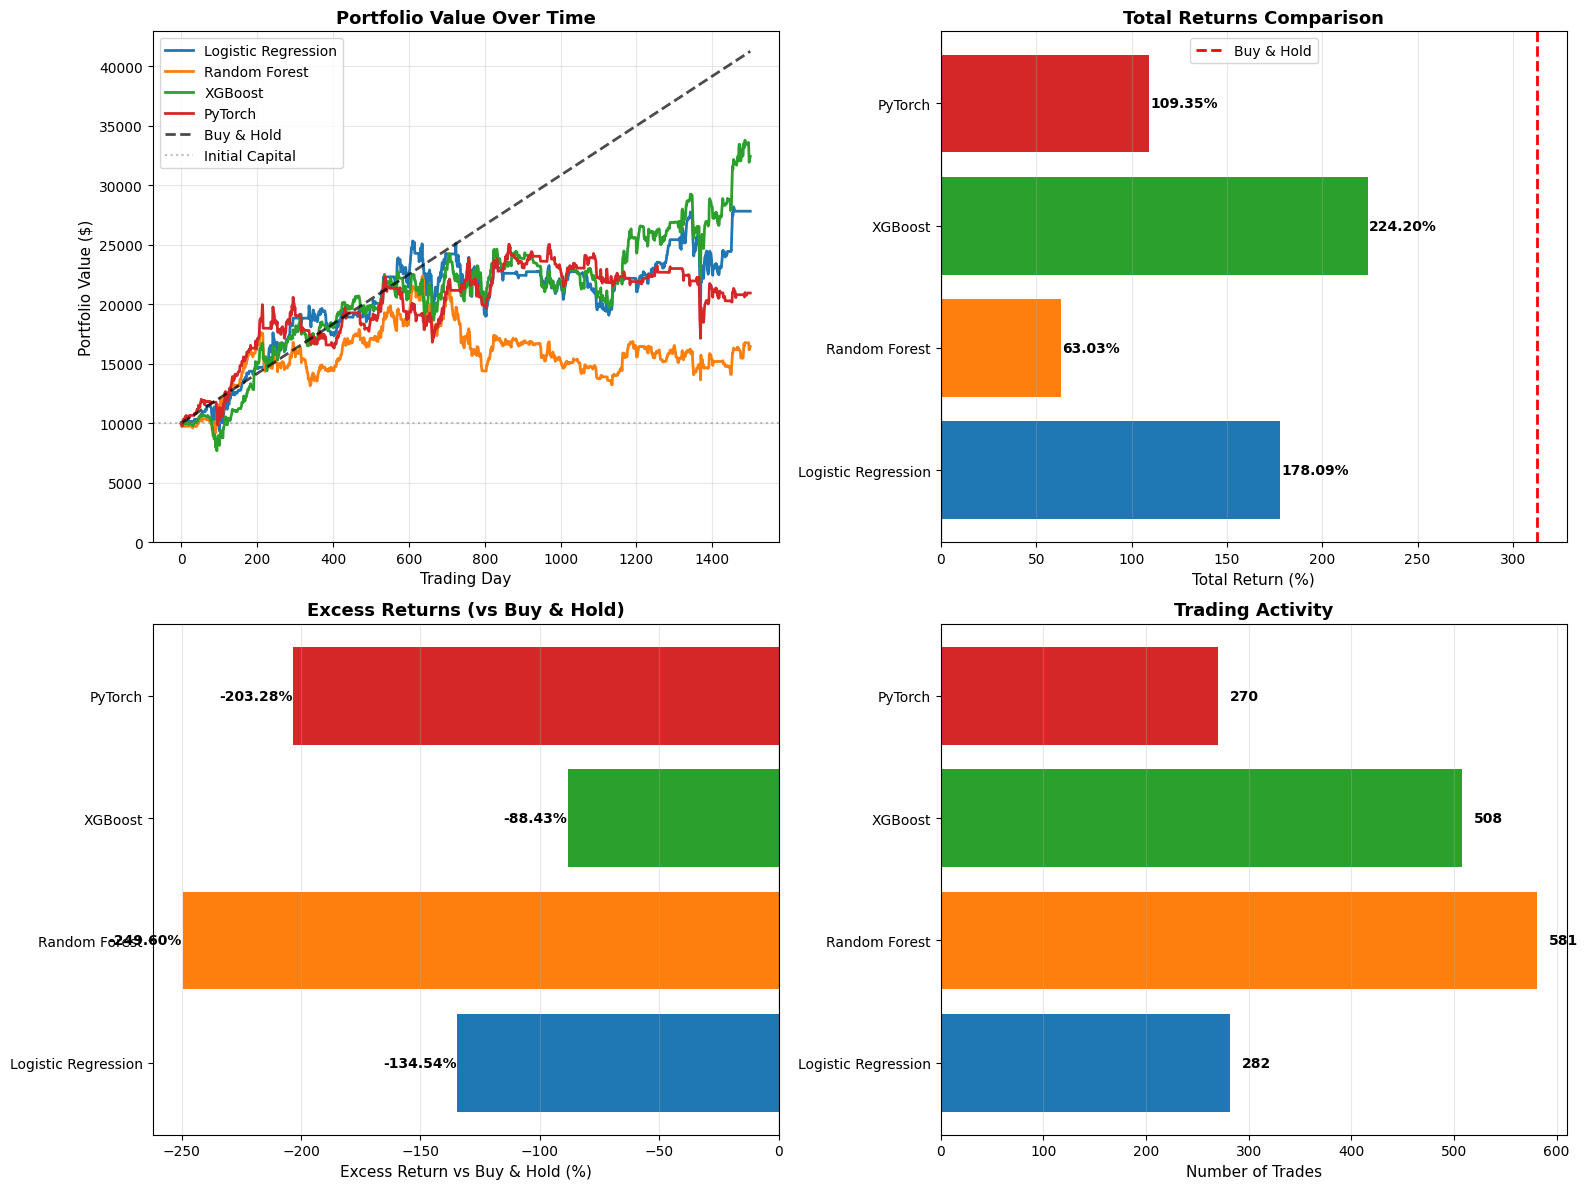

✓ Trading metrics saved to: results\trading_metrics.json


In [26]:
# Visualize trading performance
if actual_returns is not None and 'trading_results' in globals():
    print("\n" + "=" * 80)
    print("TRADING PERFORMANCE VISUALIZATION")
    print("=" * 80)
    
    fig, axes = plt.subplots(2, 2, figsize=(16, 12))
    
    # 1. Portfolio Value Over Time
    ax1 = axes[0, 0]
    for model_name, result in trading_results.items():
        portfolio_values = result['portfolio_value']
        ax1.plot(portfolio_values, label=model_name, linewidth=2)
    
    # Add buy & hold baseline
    buy_hold_values = [initial_cash * (1 + trading_results[list(trading_results.keys())[0]]['buy_hold_return'] * i / len(portfolio_values)) 
                      for i in range(len(portfolio_values))]
    ax1.plot(buy_hold_values, label='Buy & Hold', linestyle='--', linewidth=2, color='black', alpha=0.7)
    
    ax1.axhline(y=initial_cash, color='gray', linestyle=':', alpha=0.5, label='Initial Capital')
    ax1.set_xlabel('Trading Day', fontsize=11)
    ax1.set_ylabel('Portfolio Value ($)', fontsize=11)
    ax1.set_title('Portfolio Value Over Time', fontsize=13, fontweight='bold')
    ax1.legend()
    ax1.grid(True, alpha=0.3)
    ax1.set_ylim(bottom=0)
    
    # 2. Total Returns Comparison
    ax2 = axes[0, 1]
    model_names = list(trading_results.keys())
    returns = [trading_results[m]['total_return_pct'] for m in model_names]
    colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728'][:len(model_names)]
    bars = ax2.barh(model_names, returns, color=colors)
    ax2.axvline(x=0, color='black', linestyle='-', linewidth=0.8)
    ax2.axvline(x=trading_results[model_names[0]]['buy_hold_return_pct'], 
                color='red', linestyle='--', linewidth=2, label='Buy & Hold')
    ax2.set_xlabel('Total Return (%)', fontsize=11)
    ax2.set_title('Total Returns Comparison', fontsize=13, fontweight='bold')
    ax2.legend()
    ax2.grid(True, alpha=0.3, axis='x')
    
    # Add value labels on bars
    for i, (bar, ret) in enumerate(zip(bars, returns)):
        ax2.text(ret + (0.5 if ret >= 0 else -0.5), i, f'{ret:.2f}%', 
                va='center', ha='left' if ret >= 0 else 'right', fontweight='bold')
    
    # 3. Excess Returns vs Buy & Hold
    ax3 = axes[1, 0]
    excess_returns = [trading_results[m]['excess_return_pct'] for m in model_names]
    bars = ax3.barh(model_names, excess_returns, color=colors)
    ax3.axvline(x=0, color='black', linestyle='-', linewidth=0.8)
    ax3.set_xlabel('Excess Return vs Buy & Hold (%)', fontsize=11)
    ax3.set_title('Excess Returns (vs Buy & Hold)', fontsize=13, fontweight='bold')
    ax3.grid(True, alpha=0.3, axis='x')
    
    # Add value labels
    for i, (bar, exc) in enumerate(zip(bars, excess_returns)):
        ax3.text(exc + (0.2 if exc >= 0 else -0.2), i, f'{exc:.2f}%', 
                va='center', ha='left' if exc >= 0 else 'right', fontweight='bold')
    
    # 4. Number of Trades
    ax4 = axes[1, 1]
    num_trades = [trading_results[m]['num_trades'] for m in model_names]
    bars = ax4.barh(model_names, num_trades, color=colors)
    ax4.set_xlabel('Number of Trades', fontsize=11)
    ax4.set_title('Trading Activity', fontsize=13, fontweight='bold')
    ax4.grid(True, alpha=0.3, axis='x')
    
    # Add value labels
    for i, (bar, nt) in enumerate(zip(bars, num_trades)):
        ax4.text(nt + max(num_trades) * 0.02, i, f'{nt}', 
                va='center', ha='left', fontweight='bold')
    
    plt.tight_layout()
    plt.savefig(os.path.join(OUT_PLOTS_DIR, "trading_performance.png"), dpi=150, bbox_inches='tight')
    print(f"\n✓ Trading performance visualization saved to: {OUT_PLOTS_DIR}/trading_performance.png")
    plt.show()
    
    # Save trading results to JSON
    trading_metrics = {
        "initial_cash": initial_cash,
        "buy_hold_return": trading_results[model_names[0]]['buy_hold_return_pct'],
        "models": {}
    }
    
    for model_name, result in trading_results.items():
        trading_metrics["models"][model_name.lower().replace(" ", "_")] = {
            "final_value": float(result['final_value']),
            "total_return_pct": float(result['total_return_pct']),
            "excess_return_pct": float(result['excess_return_pct']),
            "num_trades": int(result['num_trades'])
        }
    
    trading_metrics_path = os.path.join(OUT_RESULTS_DIR, "trading_metrics.json")
    with open(trading_metrics_path, "w") as f:
        json.dump(trading_metrics, f, indent=2)
    print(f"✓ Trading metrics saved to: {trading_metrics_path}")
    
else:
    print("⚠️  Cannot create trading visualization - trading simulation not completed")



COMPREHENSIVE MODEL RESULTS
Showing all confusion matrices and detailed accuracy metrics for each model



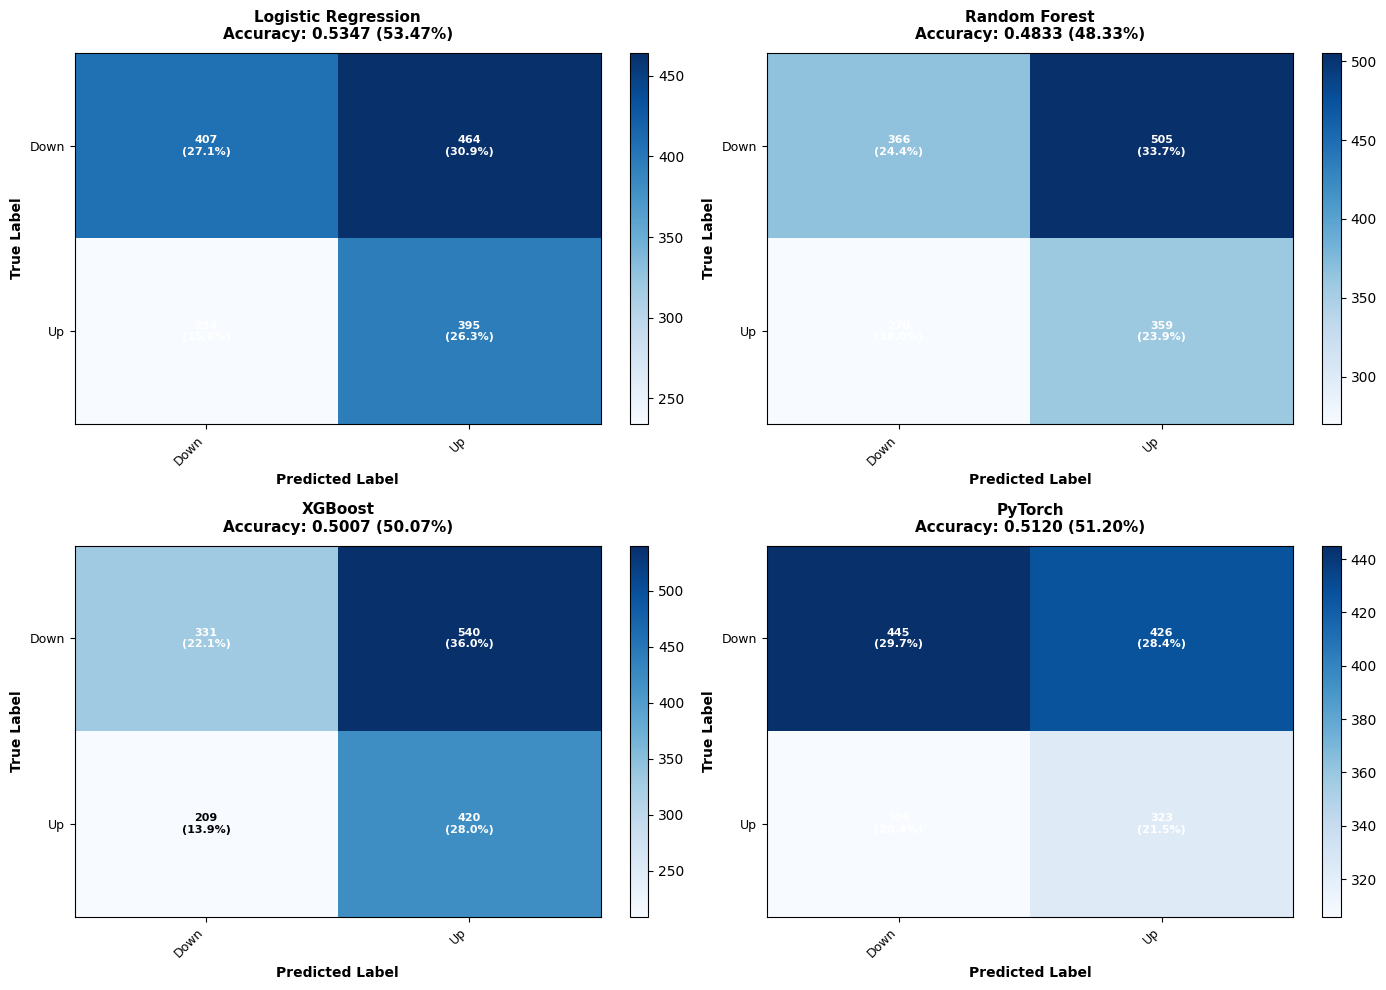


DETAILED METRICS BY MODEL

Detailed Metrics Table:
--------------------------------------------------------------------------------

LOGISTIC REGRESSION
--------------------------------------------------------------------------------
Overall Accuracy: 0.534667 (53.47%)
Macro F1-Score: 0.534637

Per-Class Breakdown:
Class  Precision   Recall  F1-Score  Support
 Down   0.634945 0.467279  0.538360      871
   Up   0.459837 0.627981  0.530914      629

RANDOM FOREST
--------------------------------------------------------------------------------
Overall Accuracy: 0.483333 (48.33%)
Macro F1-Score: 0.483322

Per-Class Breakdown:
Class  Precision   Recall  F1-Score  Support
 Down   0.575472 0.420207  0.485733      871
   Up   0.415509 0.570747  0.480911      629

XGBOOST
--------------------------------------------------------------------------------
Overall Accuracy: 0.500667 (50.07%)
Macro F1-Score: 0.498903

Per-Class Breakdown:
Class  Precision   Recall  F1-Score  Support
 Down   0.61296

In [27]:
# ========== COMPREHENSIVE MODEL RESULTS: ALL CONFUSION MATRICES & DETAILED METRICS ==========
print("\n" + "=" * 80)
print("COMPREHENSIVE MODEL RESULTS")
print("=" * 80)
print("Showing all confusion matrices and detailed accuracy metrics for each model\n")

# Calculate metrics for all models (if not already calculated)
# Logistic Regression metrics
prec_lr, rec_lr, f1_lr, sup_lr = precision_recall_fscore_support(y_test, y_pred_lr, labels=clf_lr.classes_, zero_division=0)
macro_f1_lr = np.mean(f1_lr)

# Random Forest metrics
prec_rf, rec_rf, f1_rf, sup_rf = precision_recall_fscore_support(y_test, y_pred_rf, labels=clf_rf.classes_, zero_division=0)
macro_f1_rf = np.mean(f1_rf)

# XGBoost metrics (if available)
if XGBOOST_AVAILABLE:
    prec_xgb, rec_xgb, f1_xgb, sup_xgb = precision_recall_fscore_support(y_test, y_pred_xgb, labels=sorted(np.unique(y_test)), zero_division=0)
    macro_f1_xgb = np.mean(f1_xgb)

# PyTorch metrics (if available)
if PYTORCH_AVAILABLE:
    prec_pt, rec_pt, f1_pt, sup_pt = precision_recall_fscore_support(y_test, y_pred_pt, labels=sorted(np.unique(y_test)), zero_division=0)
    macro_f1_pt = np.mean(f1_pt)

# ========== VISUALIZE ALL CONFUSION MATRICES ==========
# Determine how many models we have
num_models = 2  # Logistic Regression, Random Forest
if XGBOOST_AVAILABLE:
    num_models += 1
if PYTORCH_AVAILABLE:
    num_models += 1

# Create subplots - adjust layout based on number of models
if num_models == 2:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
elif num_models == 3:
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
elif num_models == 4:
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    axes = axes.flatten()
else:
    fig, axes = plt.subplots(1, num_models, figsize=(6*num_models, 5))

# Function to plot confusion matrix
def plot_confusion_matrix_detailed(cm, labels, title, ax, accuracy):
    im = ax.imshow(cm, interpolation="nearest", cmap='Blues', aspect='auto')
    ax.set_title(f"{title}\nAccuracy: {accuracy:.4f} ({accuracy*100:.2f}%)", 
                 fontsize=11, fontweight='bold', pad=10)
    ax.figure.colorbar(im, ax=ax, fraction=0.046)
    tick_marks = np.arange(len(labels))
    ax.set_xticks(tick_marks)
    ax.set_yticks(tick_marks)
    ax.set_xticklabels(labels, rotation=45, ha='right', fontsize=9)
    ax.set_yticklabels(labels, fontsize=9)
    ax.set_ylabel("True Label", fontsize=10, fontweight='bold')
    ax.set_xlabel("Predicted Label", fontsize=10, fontweight='bold')
    
    # Add text annotations with percentages
    thresh = cm.max() / 2.0
    total = cm.sum()
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            count = int(cm[i, j])
            pct = (count / total * 100) if total > 0 else 0
            text = f"{count}\n({pct:.1f}%)"
            ax.text(
                j, i, text,
                horizontalalignment="center",
                verticalalignment="center",
                color="white" if cm[i, j] > thresh else "black",
                fontsize=8,
                fontweight='bold'
            )

# Plot all confusion matrices
plot_confusion_matrix_detailed(
    cm_lr, 
    list(clf_lr.classes_), 
    "Logistic Regression",
    axes[0],
    acc_lr
)

plot_confusion_matrix_detailed(
    cm_rf,
    list(clf_rf.classes_),
    "Random Forest",
    axes[1],
    acc_rf
)

plot_idx = 2
if XGBOOST_AVAILABLE:
    plot_confusion_matrix_detailed(
        cm_xgb,
        sorted(np.unique(y_test)),
        "XGBoost",
        axes[plot_idx],
        acc_xgb
    )
    plot_idx += 1

if PYTORCH_AVAILABLE:
    plot_confusion_matrix_detailed(
        cm_pt,
        sorted(np.unique(y_test)),
        "PyTorch",
        axes[plot_idx],
        acc_pt
    )

plt.tight_layout()
plt.show()

# ========== DETAILED METRICS TABLE ==========
print("\n" + "=" * 80)
print("DETAILED METRICS BY MODEL")
print("=" * 80)

# Create comprehensive metrics table
all_models_data = []

# Logistic Regression
for i, cls in enumerate(clf_lr.classes_):
    all_models_data.append({
        'Model': 'Logistic Regression',
        'Class': cls,
        'Precision': prec_lr[i],
        'Recall': rec_lr[i],
        'F1-Score': f1_lr[i],
        'Support': sup_lr[i],
        'Accuracy': acc_lr if i == 0 else None,
        'Macro F1': macro_f1_lr if i == 0 else None
    })

# Random Forest
for i, cls in enumerate(clf_rf.classes_):
    all_models_data.append({
        'Model': 'Random Forest',
        'Class': cls,
        'Precision': prec_rf[i],
        'Recall': rec_rf[i],
        'F1-Score': f1_rf[i],
        'Support': sup_rf[i],
        'Accuracy': acc_rf if i == 0 else None,
        'Macro F1': macro_f1_rf if i == 0 else None
    })

# XGBoost
if XGBOOST_AVAILABLE:
    xgb_classes = sorted(np.unique(y_test))
    for i, cls in enumerate(xgb_classes):
        all_models_data.append({
            'Model': 'XGBoost',
            'Class': cls,
            'Precision': prec_xgb[i],
            'Recall': rec_xgb[i],
            'F1-Score': f1_xgb[i],
            'Support': sup_xgb[i],
            'Accuracy': acc_xgb if i == 0 else None,
            'Macro F1': macro_f1_xgb if i == 0 else None
        })

# PyTorch
if PYTORCH_AVAILABLE:
    pt_classes = sorted(np.unique(y_test))
    for i, cls in enumerate(pt_classes):
        all_models_data.append({
            'Model': 'PyTorch',
            'Class': cls,
            'Precision': prec_pt[i],
            'Recall': rec_pt[i],
            'F1-Score': f1_pt[i],
            'Support': sup_pt[i],
            'Accuracy': acc_pt if i == 0 else None,
            'Macro F1': macro_f1_pt if i == 0 else None
        })

metrics_df = pd.DataFrame(all_models_data)

# Print formatted table
print("\nDetailed Metrics Table:")
print("-" * 80)
for model_name in metrics_df['Model'].unique():
    model_data = metrics_df[metrics_df['Model'] == model_name]
    print(f"\n{model_name.upper()}")
    print("-" * 80)
    # Get overall metrics from first row
    overall_row = model_data.iloc[0]
    print(f"Overall Accuracy: {overall_row['Accuracy']:.6f} ({overall_row['Accuracy']*100:.2f}%)")
    print(f"Macro F1-Score: {overall_row['Macro F1']:.6f}")
    print("\nPer-Class Breakdown:")
    print(model_data[['Class', 'Precision', 'Recall', 'F1-Score', 'Support']].to_string(index=False))

# ========== CONFUSION MATRICES AS TABLES ==========
print("\n" + "=" * 80)
print("CONFUSION MATRICES (Detailed)")
print("=" * 80)

print("\n1. LOGISTIC REGRESSION")
print("-" * 80)
print(f"Overall Accuracy: {acc_lr:.6f} ({acc_lr*100:.2f}%)")
cm_df_lr = pd.DataFrame(cm_lr, index=clf_lr.classes_, columns=clf_lr.classes_)
print("\nConfusion Matrix:")
print(cm_df_lr.to_string())
# Add row/column totals
cm_df_lr_with_totals = cm_df_lr.copy()
cm_df_lr_with_totals['Total (Actual)'] = cm_df_lr.sum(axis=1)
cm_df_lr_with_totals.loc['Total (Predicted)'] = cm_df_lr.sum(axis=0)
cm_df_lr_with_totals.loc['Total (Predicted)', 'Total (Actual)'] = cm_df_lr.sum().sum()
print("\nWith Totals:")
print(cm_df_lr_with_totals.to_string())

print("\n2. RANDOM FOREST")
print("-" * 80)
print(f"Overall Accuracy: {acc_rf:.6f} ({acc_rf*100:.2f}%)")
cm_df_rf = pd.DataFrame(cm_rf, index=clf_rf.classes_, columns=clf_rf.classes_)
print("\nConfusion Matrix:")
print(cm_df_rf.to_string())
cm_df_rf_with_totals = cm_df_rf.copy()
cm_df_rf_with_totals['Total (Actual)'] = cm_df_rf.sum(axis=1)
cm_df_rf_with_totals.loc['Total (Predicted)'] = cm_df_rf.sum(axis=0)
cm_df_rf_with_totals.loc['Total (Predicted)', 'Total (Actual)'] = cm_df_rf.sum().sum()
print("\nWith Totals:")
print(cm_df_rf_with_totals.to_string())

if XGBOOST_AVAILABLE:
    print("\n3. XGBOOST")
    print("-" * 80)
    print(f"Overall Accuracy: {acc_xgb:.6f} ({acc_xgb*100:.2f}%)")
    xgb_classes = sorted(np.unique(y_test))
    cm_df_xgb = pd.DataFrame(cm_xgb, index=xgb_classes, columns=xgb_classes)
    print("\nConfusion Matrix:")
    print(cm_df_xgb.to_string())
    cm_df_xgb_with_totals = cm_df_xgb.copy()
    cm_df_xgb_with_totals['Total (Actual)'] = cm_df_xgb.sum(axis=1)
    cm_df_xgb_with_totals.loc['Total (Predicted)'] = cm_df_xgb.sum(axis=0)
    cm_df_xgb_with_totals.loc['Total (Predicted)', 'Total (Actual)'] = cm_df_xgb.sum().sum()
    print("\nWith Totals:")
    print(cm_df_xgb_with_totals.to_string())

if PYTORCH_AVAILABLE:
    print("\n4. PYTORCH")
    print("-" * 80)
    print(f"Overall Accuracy: {acc_pt:.6f} ({acc_pt*100:.2f}%)")
    pt_classes = sorted(np.unique(y_test))
    cm_df_pt = pd.DataFrame(cm_pt, index=pt_classes, columns=pt_classes)
    print("\nConfusion Matrix:")
    print(cm_df_pt.to_string())
    cm_df_pt_with_totals = cm_df_pt.copy()
    cm_df_pt_with_totals['Total (Actual)'] = cm_df_pt.sum(axis=1)
    cm_df_pt_with_totals.loc['Total (Predicted)'] = cm_df_pt.sum(axis=0)
    cm_df_pt_with_totals.loc['Total (Predicted)', 'Total (Actual)'] = cm_df_pt.sum().sum()
    print("\nWith Totals:")
    print(cm_df_pt_with_totals.to_string())

print("\n" + "=" * 80)
print("END OF COMPREHENSIVE RESULTS")
print("=" * 80)


MODEL COMPARISON

Model Comparison:
              Model  Accuracy  Macro F1
Logistic Regression  0.534667  0.534637
            PyTorch  0.512000  0.508750
            XGBoost  0.500667  0.498903
      Random Forest  0.483333  0.483322


<Figure size 1000x600 with 0 Axes>

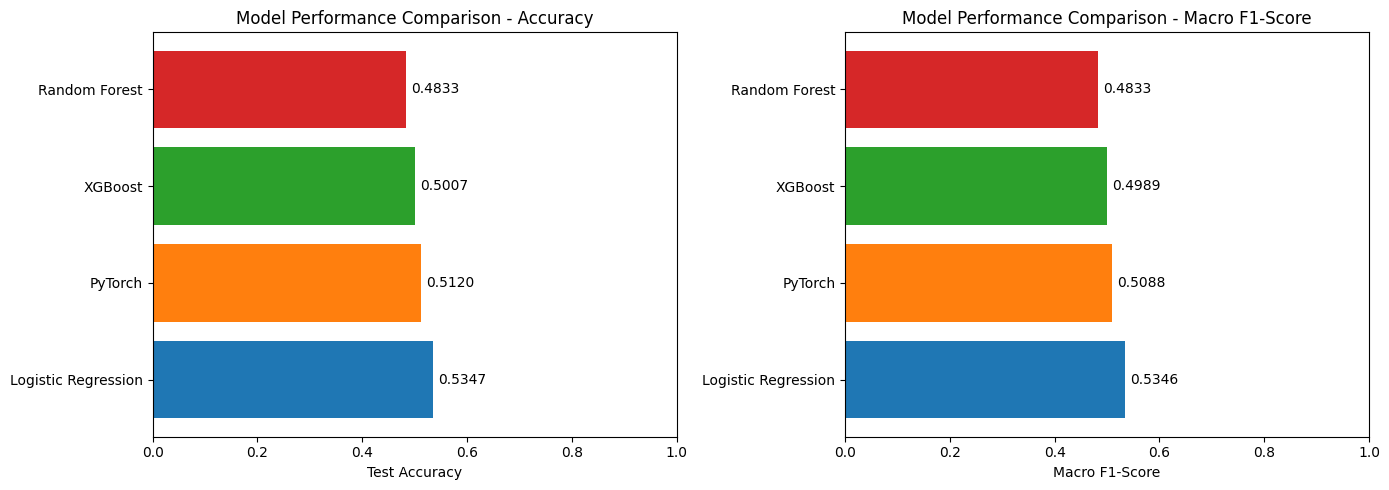


All metrics saved to: results\metrics.json


In [28]:
# Compare all models
print("=" * 60)
print("MODEL COMPARISON")
print("=" * 60)

# Calculate macro F1-scores for each model
prec_lr, rec_lr, f1_lr, sup_lr = precision_recall_fscore_support(y_test, y_pred_lr, labels=clf_lr.classes_, zero_division=0)
macro_f1_lr = np.mean(f1_lr)

prec_rf, rec_rf, f1_rf, sup_rf = precision_recall_fscore_support(y_test, y_pred_rf, labels=clf_rf.classes_, zero_division=0)
macro_f1_rf = np.mean(f1_rf)

models_comparison = {
    "Logistic Regression": {"Accuracy": acc_lr, "Macro F1": macro_f1_lr},
    "Random Forest": {"Accuracy": acc_rf, "Macro F1": macro_f1_rf},
}

if XGBOOST_AVAILABLE:
    prec_xgb, rec_xgb, f1_xgb, sup_xgb = precision_recall_fscore_support(y_test, y_pred_xgb, labels=sorted(np.unique(y_test)), zero_division=0)
    macro_f1_xgb = np.mean(f1_xgb)
    models_comparison["XGBoost"] = {"Accuracy": acc_xgb, "Macro F1": macro_f1_xgb}

if PYTORCH_AVAILABLE:
    prec_pt, rec_pt, f1_pt, sup_pt = precision_recall_fscore_support(y_test, y_pred_pt, labels=sorted(np.unique(y_test)), zero_division=0)
    macro_f1_pt = np.mean(f1_pt)
    models_comparison["PyTorch"] = {"Accuracy": acc_pt, "Macro F1": macro_f1_pt}

comparison_df = pd.DataFrame(models_comparison).T.reset_index()
comparison_df.columns = ["Model", "Accuracy", "Macro F1"]
comparison_df = comparison_df.sort_values("Accuracy", ascending=False)

print("\nModel Comparison:")
print(comparison_df.to_string(index=False))

# Visualize comparison - Accuracy
plt.figure(figsize=(10, 6))
x = np.arange(len(comparison_df))
width = 0.35

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Accuracy comparison
colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd'][:len(comparison_df)]
ax1.barh(comparison_df["Model"], comparison_df["Accuracy"], color=colors)
ax1.set_xlabel("Test Accuracy")
ax1.set_title("Model Performance Comparison - Accuracy")
ax1.set_xlim([0, 1])
for i, v in enumerate(comparison_df["Accuracy"]):
    ax1.text(v + 0.01, i, f'{v:.4f}', va='center')

# Macro F1 comparison
ax2.barh(comparison_df["Model"], comparison_df["Macro F1"], color=colors)
ax2.set_xlabel("Macro F1-Score")
ax2.set_title("Model Performance Comparison - Macro F1-Score")
ax2.set_xlim([0, 1])
for i, v in enumerate(comparison_df["Macro F1"]):
    ax2.text(v + 0.01, i, f'{v:.4f}', va='center')

plt.tight_layout()
plt.show()

# Save metrics
metrics = {
    "train_fraction": train_frac,
    "num_features": len(feature_cols),
    "num_train_rows": len(train_df),
    "num_test_rows": len(test_df),
    "models": {},
    "datetime": datetime.utcnow().isoformat() + "Z"
}

# Add metrics for each model (using already calculated values from comparison section)
metrics["models"]["logistic_regression"] = {
    "accuracy": float(acc_lr),
    "macro_f1": float(macro_f1_lr),
    "per_class_metrics": {
        cls: {"precision": float(p), "recall": float(r), "f1": float(f), "support": int(s)}
        for cls, p, r, f, s in zip(clf_lr.classes_, prec_lr, rec_lr, f1_lr, sup_lr)
    }
}

metrics["models"]["random_forest"] = {
    "accuracy": float(acc_rf),
    "macro_f1": float(macro_f1_rf),
    "per_class_metrics": {
        cls: {"precision": float(p), "recall": float(r), "f1": float(f), "support": int(s)}
        for cls, p, r, f, s in zip(clf_rf.classes_, prec_rf, rec_rf, f1_rf, sup_rf)
    }
}

if XGBOOST_AVAILABLE:
    metrics["models"]["xgboost"] = {
        "accuracy": float(acc_xgb),
        "macro_f1": float(macro_f1_xgb),
        "per_class_metrics": {
            cls: {"precision": float(p), "recall": float(r), "f1": float(f), "support": int(s)}
            for cls, p, r, f, s in zip(sorted(np.unique(y_test)), prec_xgb, rec_xgb, f1_xgb, sup_xgb)
        }
    }

if PYTORCH_AVAILABLE:
    metrics["models"]["pytorch"] = {
        "accuracy": float(acc_pt),
        "macro_f1": float(macro_f1_pt),
        "per_class_metrics": {
            cls: {"precision": float(p), "recall": float(r), "f1": float(f), "support": int(s)}
            for cls, p, r, f, s in zip(sorted(np.unique(y_test)), prec_pt, rec_pt, f1_pt, sup_pt)
        }
    }

metrics_path = os.path.join(OUT_RESULTS_DIR, "metrics.json")
with open(metrics_path, "w") as f:
    json.dump(metrics, f, indent=2, default=str)
print(f"\nAll metrics saved to: {metrics_path}")


# Chart

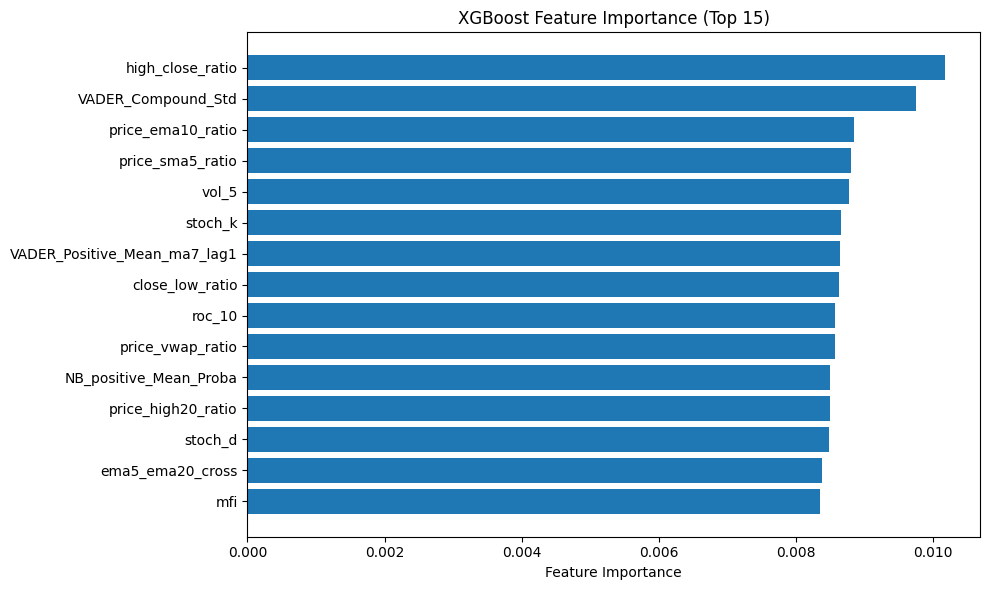

In [29]:
# Visualize XGBoost feature importance
if XGBOOST_AVAILABLE:
    plt.figure(figsize=(10, 6))
    top_features = feature_importance_df_xgb.head(15)
    plt.barh(range(len(top_features)), top_features['importance'].values)
    plt.yticks(range(len(top_features)), top_features['feature'].values)
    plt.xlabel("Feature Importance")
    plt.title("XGBoost Feature Importance (Top 15)")
    plt.gca().invert_yaxis()
    plt.tight_layout()
    plt.show()
else:
    print("XGBoost not available for feature importance visualization.")


## All Confusion Matrices

Display all confusion matrices for easy comparison across models.


ALL CONFUSION MATRICES


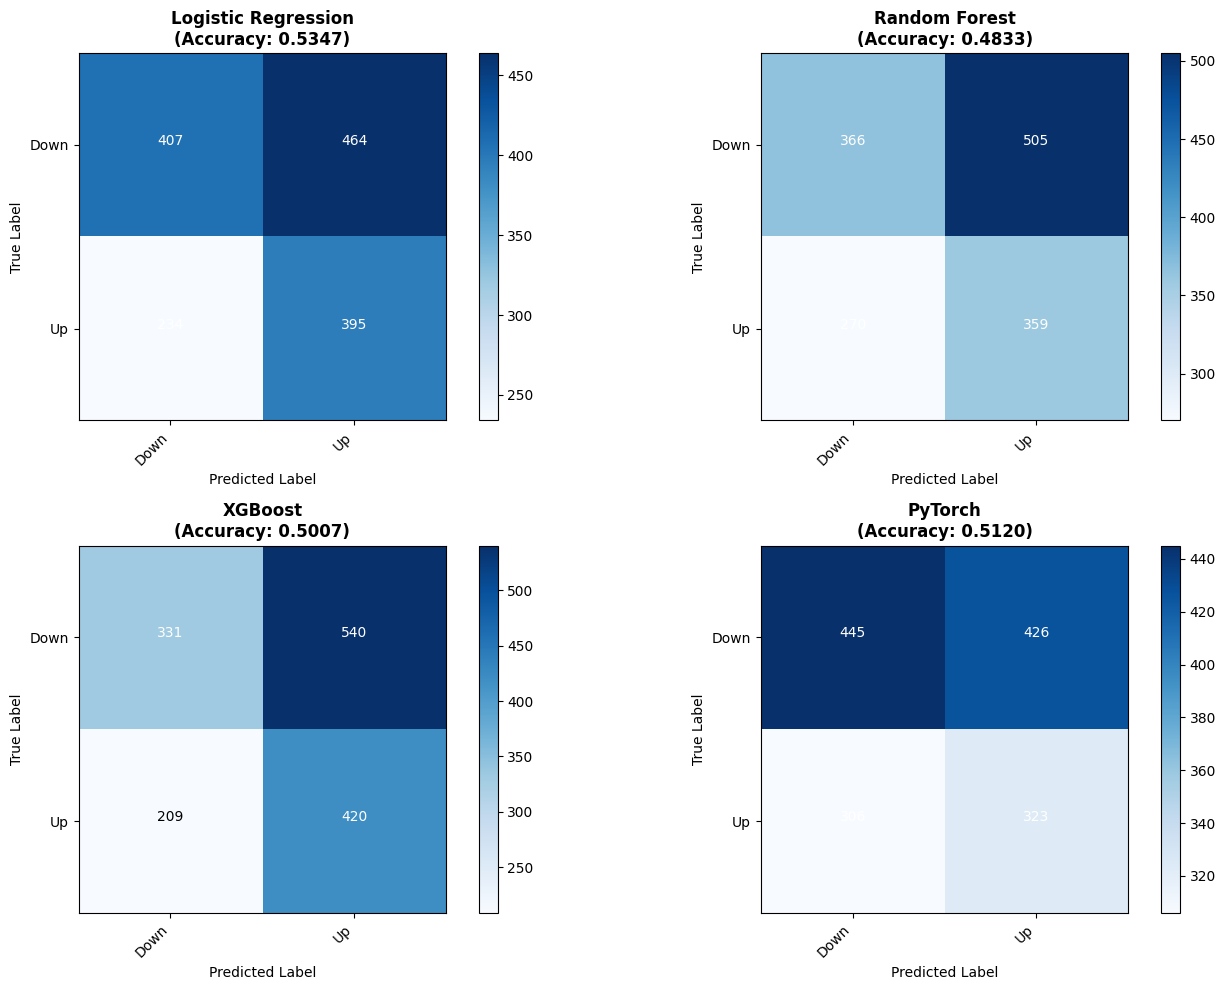


CONFUSION MATRIX VALUES (for reference)

1. Logistic Regression Confusion Matrix:
   Classes: ['Down', 'Up']
      Down   Up
Down   407  464
Up     234  395

2. Random Forest Confusion Matrix:
   Classes: ['Down', 'Up']
      Down   Up
Down   366  505
Up     270  359

3. XGBoost Confusion Matrix:
   Classes: ['Down', 'Up']
      Down   Up
Down   331  540
Up     209  420

4. PyTorch Confusion Matrix:
   Classes: ['Down', 'Up']
      Down   Up
Down   445  426
Up     306  323


In [30]:
# Display all confusion matrices
print("=" * 70)
print("ALL CONFUSION MATRICES")
print("=" * 70)

# Function to plot confusion matrix inline (for display)
def plot_confusion_matrix_inline(cm, labels, title, ax):
    im = ax.imshow(cm, interpolation="nearest", cmap='Blues')
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.figure.colorbar(im, ax=ax)
    tick_marks = np.arange(len(labels))
    ax.set_xticks(tick_marks)
    ax.set_yticks(tick_marks)
    ax.set_xticklabels(labels, rotation=45, ha='right')
    ax.set_yticklabels(labels)
    ax.set_ylabel("True Label", fontsize=10)
    ax.set_xlabel("Predicted Label", fontsize=10)
    
    # Add text annotations
    thresh = cm.max() / 2.0
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            ax.text(
                j, i, format(int(cm[i, j]), "d"),
                horizontalalignment="center",
                color="white" if cm[i, j] > thresh else "black",
                fontsize=10
            )

# Determine how many models we have
num_models = 2  # Logistic Regression and Random Forest
if XGBOOST_AVAILABLE:
    num_models += 1
if PYTORCH_AVAILABLE:
    num_models += 1

# Create subplots
if num_models == 2:
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
elif num_models == 3:
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
elif num_models == 4:
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    axes = axes.flatten()
else:
    fig, axes = plt.subplots(1, num_models, figsize=(6*num_models, 5))

# Plot Logistic Regression confusion matrix
plot_confusion_matrix_inline(
    cm_lr, 
    list(clf_lr.classes_), 
    f"Logistic Regression\n(Accuracy: {acc_lr:.4f})",
    axes[0]
)

# Plot Random Forest confusion matrix
plot_confusion_matrix_inline(
    cm_rf,
    list(clf_rf.classes_),
    f"Random Forest\n(Accuracy: {acc_rf:.4f})",
    axes[1]
)

# Plot XGBoost confusion matrix if available
plot_idx = 2
if XGBOOST_AVAILABLE:
    plot_confusion_matrix_inline(
        cm_xgb,
        sorted(np.unique(y_test)),
        f"XGBoost\n(Accuracy: {acc_xgb:.4f})",
        axes[plot_idx]
    )
    plot_idx += 1

# Plot PyTorch confusion matrix if available
if PYTORCH_AVAILABLE:
    plot_confusion_matrix_inline(
        cm_pt,
        sorted(np.unique(y_test)),
        f"PyTorch\n(Accuracy: {acc_pt:.4f})",
        axes[plot_idx]
    )

plt.tight_layout()
plt.show()

# Also print the confusion matrices as tables
print("\n" + "=" * 70)
print("CONFUSION MATRIX VALUES (for reference)")
print("=" * 70)

print("\n1. Logistic Regression Confusion Matrix:")
print("   Classes:", list(clf_lr.classes_))
cm_df_lr = pd.DataFrame(cm_lr, index=clf_lr.classes_, columns=clf_lr.classes_)
print(cm_df_lr)

print("\n2. Random Forest Confusion Matrix:")
print("   Classes:", list(clf_rf.classes_))
cm_df_rf = pd.DataFrame(cm_rf, index=clf_rf.classes_, columns=clf_rf.classes_)
print(cm_df_rf)

if XGBOOST_AVAILABLE:
    print("\n3. XGBoost Confusion Matrix:")
    print("   Classes:", sorted(np.unique(y_test)))
    cm_df_xgb = pd.DataFrame(cm_xgb, index=sorted(np.unique(y_test)), columns=sorted(np.unique(y_test)))
    print(cm_df_xgb)

if PYTORCH_AVAILABLE:
    print("\n4. PyTorch Confusion Matrix:")
    print("   Classes:", sorted(np.unique(y_test)))
    cm_df_pt = pd.DataFrame(cm_pt, index=sorted(np.unique(y_test)), columns=sorted(np.unique(y_test)))
    print(cm_df_pt)
